In [167]:
import pickle
import os
import copy
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns


In [73]:
# Helper
def parse_task_by_dirname(root_path, simulation_dir):
    if 'name_format_1' in root_path: # DEPREACTED
        task_string = simulation_dir.split('_')[-1]
        task_type = task_string[:-1]
        task_seed = 0
        task_level = task_string[-1]
    
    # elif 'name_format_2' in root_path:
    else:
        task_string = simulation_dir.split('T')[-1]
        task_string_splitted = task_string.split('_')
        task_type = task_string_splitted[0]
        assert len(task_string_splitted) == 3, f'task string {task_string} is not in the correct format'
        assert task_string_splitted[1][0] == 's' and task_string_splitted[2][0] == 'l', f'task string {task_string} is not in the correct format'
        task_seed = int(task_string_splitted[1][1:])
        task_level = int(task_string_splitted[2][1:])
    # else:
    #     raise ValueError(f'root path {root_path} not supported')
    assert task_type in ['bin', 'reach','manual','follow'], f'task type {task_type} not supported'
    return task_type, task_seed, task_level

def parse_sim_info_by_dirname(root_path, simulation_dir):
    if 'name_format_1' in root_path:
        # example: 2025-08-16_16:43:16_ur5e4O_bin3 
        splitted_string = simulation_dir.split('_')
        timestamp = splitted_string[0] + '_' + splitted_string[1]
        robot_arms_alg = splitted_string[2]
        n_arms = 4
        robot_name, alg = robot_arms_alg.split('4')
        assert robot_name in ['ur5e','ur10e'], f'robot_name {robot_name} is not valid'
        task_parsed = parse_task_by_dirname(root_path, simulation_dir)
        task_type, task_seed, task_level = task_parsed
        
        
        # ans = timestamp, robot_name, n_arms, alg, task_type, task_seed, task_level
    else:  
    # elif 'name_format_2' in root_path:
        # example: # 2025-08-16_16:43:16_ur5e4O_bin3 
        splitted_string = simulation_dir.split('_')
        timestamp = splitted_string[0] + '_' + splitted_string[1]
        robot_name = splitted_string[3]
        n_arms = int(splitted_string[4][1:])
        alg = splitted_string[5][1:]
        task_parsed = parse_task_by_dirname(root_path, simulation_dir)
        task_type, task_seed, task_level = task_parsed

        # ans =  timestamp, robot_name, n_arms, alg, task_type, task_seed, task_level
    # else:
    #     raise ValueError(f'root path {root_path} not supported')
    
    return {'timestamp':timestamp, 'robot_name':robot_name, 'n_arms':n_arms, 'alg':alg, 'task_type':task_type, 'task_seed':task_seed, 'task_level':task_level}


In [74]:
# # Helper
# import dataclasses

# @dataclasses.dataclass
# class DataSet:
#     algs: list[str]
#     seeds: list[int]
#     tasks: list[str]
#     levels: list[list[int]]


# class DataSetDir:
#     def __init__(self, dataset_requirements: DataSet, root_path: str):
#         self.dataset_requirements = dataset_requirements
#         self.root_path = root_path
#         self.required_dirs = list(self.get_required())        
#         self.found_dirs = self.get_found(root_path)
        
#     def get_required(self):
#         for alg in self.dataset_requirements.algs:
#             for seed in self.dataset_requirements.seeds:
#                 for i, task in enumerate(self.dataset_requirements.tasks):
#                     for level in self.dataset_requirements.levels[i]:
#                         yield alg, seed, task, level

#     def get_found(self, root_path):
#         dirs = os.listdir(root_path)
#         found = []
#         for dir in dirs:
#             parsed_dir = parse_sim_info_by_dirname(root_path, dir)
#             alg, seed, task, level = parsed_dir['alg'], parsed_dir['task_seed'], parsed_dir['task_type'], parsed_dir['task_level']
#             combo = (alg, seed, task, level) 
#             found.append(combo)
#         return found
    
#     def get_missing(self):
#         return list(set(self.required_dirs) - set(self.found_dirs))
    

   
# all_algs = ['O','O-','CC','SD','SC']
# all_seeds = [0,1,2]
# all_tasks = ['bin','reach','follow']
# all_levels = [list(range(1,7)), list(range(1,7)), list(range(1,19))]
# dataset_name_to_obj = {}
# dataset_name_to_obj['aug18'] = DataSet(algs=all_algs, seeds=all_seeds, tasks=all_tasks, levels=[[1,2,3,4,5],[1,2,3,4,5,6],[4,5,6,10,11,12]])
 


# Datasets

In [75]:

verified_SC_SD_CC_Omin_follow_reach_old = "/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/verified"
O_5000_3_follow_reach_old = '/home/dan/mr_mpc_logs/BATCH_2025-08-29_20:26:36'
O_tune_follow_reach_old = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/require_verification/moved_on_22_08/tuning_O'
batch_01_09_follow_reach_new = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/require_verification/1_9_reach_follow_new/reach_follow_new_batch1'
batch_01_09_follow_reach_new_bugfix_in_logging_cols = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/require_verification/1_9_reach_follow_new/reach_follow_new_batch2_col_detection_fix/unzipped'
debug1_col_logging = '/home/dan/mr_mpc_logs/BATCH_2025-09-01_19:42:36'



# _01_09_O_1 = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/require_verification/1_9_reach_follow_new/reach_follow_new_batch2_col_detection_fix/O_w5000_cov0.5_trust3_safety03' 
# _01_09_O_2 =  '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/require_verification/1_9_reach_follow_new/reach_follow_new_batch2_col_detection_fix/O_w5000_cov0.5_trust3_safety03_B'
# _01_09_0_3 = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/require_verification/1_9_reach_follow_new/reach_follow_new_batch2_col_detection_fix/O_w5000_cov0.5_trust1_safety03'
# _O1_09_0_4 = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/require_verification/1_9_reach_follow_new/reach_follow_new_batch2_col_detection_fix/O_w5000_cov0.5_trust5_safety03'
verified_01_09 = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/verified_01_09'
# O_root_01_09 = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/require_verification/1_9_reach_follow_new/O'
O_w5000_cov05_trust5_thresh030 = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/require_verification/1_9_reach_follow_new/tmp/O_w5000_cov0.5_trust5_safety03'
O_w5000_cov05_trust3_thresh030 = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/require_verification/1_9_reach_follow_new/O/O_w5000_cov0.5_trust3_safety03' # '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/require_verification/1_9_reach_follow_new/tmp/O_w5000_cov0.5_trust3_safety03'
O_w5000_cov05_trust1_thresh030 = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/require_verification/1_9_reach_follow_new/O/O_w5000_cov0.5_trust1_safety03'
O_w5000_cov05_trust3_thresh020 = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/02_09/BATCH_2025-09-02_13:31:16_job6442201'

O_w5000_cov05_trust3_thresh025 = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/02_09/BATCH_2025-09-02_13:33:48_job6442396'
O_w3000_cov05_trust3_thresh030 = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/02_09/BATCH_2025-09-02_13:36:23_job6442528'
O_w5000_cov05_trust4_thresh030 = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/02_09/BATCH_2025-09-02_13:38:51_job6442704'
O_w5000_cov03_trust3_thresh030 = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/02_09/BATCH_2025-09-02_13:41:53_job6443025'
O_w7000_cov05_trust3_thresh030 = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/02_09/BATCH_2025-09-02_13:43:55_job6443312'
O_w7000_cov05_trust3_thresh020 = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/02_09/BATCH_2025-09-02_13:45:55_job6443532'
O_w7000_cov05_trust4_thresh020 = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/02_09/BATCH_2025-09-02_13:46:25_job6443613'
O_w10000_cov05_trust3_thresh020 ='/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/02_09/BATCH_2025-09-02_18:42:30_job6446396'
O_w15000_cov05_trust3_thresh010 = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/02_09/BATCH_2025-09-02_18:44:06_job6446399'
O_w5000_cov05_trust2_thresh020 = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/02_09/BATCH_2025-09-02_18:46:07_job6446403'
O_w5000_cov02_trust3_thresh020 = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/02_09/BATCH_2025-09-02_18:53:31_job6446416'
O_w5000_cov02_trust4_thresh020 = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/02_09/BATCH_2025-09-02_18:54:40_job6446418'
SC_800 = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/02_09/BATCH_2025-09-02_18:24:59_job6446333'
SC_1600 = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/02_09/BATCH_2025-09-02_18:27:31_job6446337'
CC_IK64 = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/02_09/BATCH_2025-09-02_18:37:04_job6446391'
SD_REACH_0309_10LEVELS = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/03_09/BATCH_2025-09-03_14:44:41_job6452622'
Omin_REACH_0309_10LEVELS = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/03_09/BATCH_2025-09-03_14:45:13_job6452624'
ALL_REACH_0309_10LEVELS = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/03_09/verified/REACH_10LEVELS' 
_0309_full_O_N400_H40_cov05_trust3_w5000_th03 = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/03_09/full/O/N400_H40_cov05_trust3_w5000_th03'
_03_09_full_all = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/03_09/full'

# Input config

In [76]:
root_paths = [_03_09_full_all] #[tmp_O_w5000_cov05_trust3, verified_01_09] # batch_01_09_follow_reach_new_bugfix_in_logging_cols # change this to the root path of the simulations you want to check
dataset = ''
verify = False # verify = True
O_tuning = True
n_max = 400 # max number of simulations to load (to prevent ram errors load at most 1000)
exclude_substrings = ['V1_BEFORE_0109'] # 'Tfollow','Tbin'] # Exclude old version reach and follow simulations
load_only = {
    'task_type': ['bin','reach','follow'], # ['reach', 'follow', 'bin']
    'alg':['O','O-','SC','SD','CC'], # ['O','O-','SC','SD','CC']
    }
tuning_load_only = {} # empty means load all
# tuning_load_only = {
#     'weight': [5000,10000,15000,20000], 
#     'trust':[3], # 1,2,2.5,3,4, 
#     'cov': [0.5] # [0.05, 0.1,0.15,0.2,0.3, 0.4, 0.5,0.8] # ,0.25,0.3,0.5
# }

# Input info

## Process pickle files of sims: this may take a few minutes. Look at the printed log to follow the process

In [77]:
import yaml
def should_load_sim(sim_dir_path,load_settings={},tuning_settings={}):
    root, sim_dir_name = os.path.split(sim_dir_path)
    sim_info = parse_sim_info_by_dirname(root, sim_dir_name)
    
    
    
    for set_name in load_settings:
        if sim_info[set_name] not in load_settings[set_name]:
            return False

    particle_file = os.path.join(sim_dir_path,'particle_cfg.yml')
    if sim_info['alg'] == 'O' and os.path.exists(particle_file) and len(tuning_settings):
        with open(particle_file, 'r') as f:
            particle_cfg = yaml.load(f, Loader=yaml.FullLoader)
            w = particle_cfg['cost']['custom']['arm_base']['dynamic_obs_cost']['weight']
            if w not in tuning_settings['weight']:
                return False
            
            t = particle_cfg['cost']['custom']['arm_base']['dynamic_obs_cost']['wta_trust']
            if t not in tuning_settings['trust']:
                return False
            c = particle_cfg['mppi']['init_cov']
            if c not in tuning_settings['cov']:
                return False
            
            print(f'Found sim with: {w,t,c}')
    
    return True

        

    # return {'timestamp':timestamp, 'robot_name':robot_name, 'n_arms':n_arms, 'alg':alg, 'task_type':task_type, 'task_seed':task_seed, 'task_level':task_level}

    
     
    


In [78]:
def find_sims_in_tree(root_path,exclude_substrings=[]):
    sim_paths = []
    for root, dirs, files in os.walk(root_path):
        for file in files:
            if file.endswith('.pkl'):
                full_path = os.path.join(root, file)
                exclude = False
                for exclude_substring in exclude_substrings:
                    print(f'Checking if {exclude_substring} is in {full_path}')
                    if exclude_substring in full_path:
                        print(f'Found {exclude_substring} in {full_path}')
                        exclude = True
                        break
                if not exclude:
                    sim_paths.append(full_path)
    return sim_paths
 

In [79]:
 
simulation_dirs = []
for root_tree in root_paths:
    simulation_dirs += find_sims_in_tree(root_tree, exclude_substrings) #os.listdir(root_path)


n_sims = len(simulation_dirs)
n_load = min(n_sims,n_max)
sim_names = []
sim_stats = []
sim_paths = []
print(f'Loading {n_load} simulations pickle files...')
loaded = 0
for i, sim_pkl_path in enumerate(simulation_dirs):
    if loaded >= n_max:
        break
    print(f'    Checking Simulation {i+1} out of{n_load} (loaded = {loaded})')
    # sim_path = os.path.join(root_path,sim_dir)
    try:
        sim_dir_path, pkl_name = os.path.split(sim_pkl_path)
        sim_name = os.path.splitext(sim_dir_path)[1]
        if not should_load_sim(sim_dir_path,load_only, tuning_load_only):
            continue

        # Load
        print(f'    Loading Simulation dir: {sim_dir_path} ')
        print('-'*100)
    
        # stats_path = os.path.join(root_path, sim_dir, stat_file_name)
        # stats_path = os.path.join(sim_dir_path, pkl_name)
        if os.path.exists(sim_pkl_path):
            with open(sim_pkl_path, 'rb') as f:
                stats = pickle.load(f)
                sim_paths.append(sim_dir_path)
                sim_names.append(sim_name)
                sim_stats.append(stats)
            # print(stats)
            loaded += 1
    
    except:
        print(f'Stats file not found for simulation {i}) {sim_pkl_path}')
        print('-'*100)

    





Checking if V1_BEFORE_0109 is in /home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/03_09/full/CC/IK32/2025-09-01_16:28:56_R_ur5e_N4_ACC_Tfollow_s2_l2/stats.pkl
Checking if V1_BEFORE_0109 is in /home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/03_09/full/CC/IK32/2025-08-18_14:53:53_R_ur5e_N4_ACC_Tbin_s0_l3/stats.pkl
Checking if V1_BEFORE_0109 is in /home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/03_09/full/CC/IK32/2025-09-01_16:25:49_R_ur5e_N4_ACC_Tfollow_s1_l2/stats.pkl
Checking if V1_BEFORE_0109 is in /home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/03_09/full/CC/IK32/2025-09-01_16:43:46_R_ur5e_N4_ACC_Tfollow_s0_l4/stats.pkl
Checking if V1_BEFORE_0109 is in /home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/03_09/full/CC/IK32/2025-09-01_16:57:21_R_ur5e_N4_ACC_Tfollow_s1_l5/stats.pkl
Checking if V1_BEFORE_0109 is in /home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/03_09/full/CC/IK32/2025-09-01_16:54:51_R_ur5e_N4_ACC_T

In [80]:
def get_statman_keys(statman_data):
    return stats[statman_data].keys()

def get_stat_keys(statman_data, stat_name):
    return statman_data[stat_name].keys()

def get_stat_vals(statman_data, stat_name):
    return statman_data[stat_name]

def get_sim_keys(sim_name, sim_stats):
    for sm_name in sim_stats.keys(): # statman name
        for stat_name in sim_stats[sm_name].keys():
            print(f'simname: {sim_name}, sman: {sm_name}, s:{stat_name}')


Sim info

In [81]:
show_sim_info = False
if show_sim_info:
    for sim_name, sim_stat in zip(sim_names, sim_stats):
        print(f'Sim info:')
        get_sim_keys(sim_name, sim_stat)
        print('')

    

In [82]:
# Helper and classes to manage sims

def find_task_statman_name(stats):
    for statman_name in stats.keys():
        if 'agent' not in statman_name:
            return statman_name
    return None

def find_agent_statman_names(stats):
    agent_statman_names = []
    for statman_name in stats.keys():
        if 'agent' in statman_name:
            agent_statman_names.append(statman_name)
    return agent_statman_names

def get_stat_from_statman(statman, stat_name, keys='all'):
    stat = statman[stat_name]
    if keys == 'all':
        return stat
    
    stat_filtered = []
    for stat_keys,stat_vals in stat.items():
        filtered_entry_keys = {}
        for key in keys:
            if key in stat_keys:
                filtered_entry_keys[key] = stat_vals[key]
                filtered_entry_vals = stat_vals
                stat_filtered.append((filtered_entry_keys,filtered_entry_vals))
    return stat_filtered
    
    
def split_task_to_k_v(stat):
    k = []
    v = []
    for item in stat:
        k.append(item[0])
        v.append(item[1])
    return k, v

def parse_task_by_dirname(root_path, simulation_dir):
    if 'name_format_1' in root_path:
        task_string = simulation_dir.split('_')[-1]
        task_type = task_string[:-1]
        task_seed = 0
        task_level = task_string[-1]
    
    # elif 'name_format_2' in root_path:
    else:
        task_string = simulation_dir.split('T')[-1]
        task_string_splitted = task_string.split('_')
        task_type = task_string_splitted[0]
        assert len(task_string_splitted) == 3, f'task string {task_string} is not in the correct format'
        assert task_string_splitted[1][0] == 's' and task_string_splitted[2][0] == 'l', f'task string {task_string} is not in the correct format'
        task_seed = int(task_string_splitted[1][1:])
        task_level = int(task_string_splitted[2][1:])
    # else:
    #     raise ValueError(f'root path {root_path} not supported')
    assert task_type in ['bin', 'reach','manual','follow'], f'task type {task_type} not supported'
    return task_type, task_seed, task_level

    

def parse_sim_info_by_dirname(root_path, simulation_dir):
    if 'name_format_1' in root_path:
        # example: 2025-08-16_16:43:16_ur5e4O_bin3 
        splitted_string = simulation_dir.split('_')
        timestamp = splitted_string[0] + '_' + splitted_string[1]
        robot_arms_alg = splitted_string[2]
        n_arms = 4
        robot_name, alg = robot_arms_alg.split('4')
        assert robot_name in ['ur5e','ur10e'], f'robot_name {robot_name} is not valid'
        task_parsed = parse_task_by_dirname(root_path, simulation_dir)
        task_type, task_seed, task_level = task_parsed
        
        
        # ans = timestamp, robot_name, n_arms, alg, task_type, task_seed, task_level
    else:  
    # elif 'name_format_2' in root_path:
        # example: # 2025-08-16_16:43:16_ur5e4O_bin3 
        splitted_string = simulation_dir.split('_')
        timestamp = splitted_string[0] + '_' + splitted_string[1]
        robot_name = splitted_string[3]
        n_arms = int(splitted_string[4][1:])
        alg = splitted_string[5][1:]
        task_parsed = parse_task_by_dirname(root_path, simulation_dir)
        task_type, task_seed, task_level = task_parsed

        # ans =  timestamp, robot_name, n_arms, alg, task_type, task_seed, task_level
    # else:
    #     raise ValueError(f'root path {root_path} not supported')
    
    return {'timestamp':timestamp, 'robot_name':robot_name, 'n_arms':n_arms, 'alg':alg, 'task_type':task_type, 'task_seed':task_seed, 'task_level':task_level}


class SimStats:
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        self.task_stats_parsed = []
        self.meta_data = meta_data
        self.sim_stats = sim_stats
        self.task_stats = sim_stats['task_stats']
        agents_statman_names = [x for x in sim_stats.keys() if 'agent' in x]
        agents_statman_names.sort(key=lambda x: int(x.split('_')[-1])) # sort by agent index
        self.agent_stats = []
        for statman_name in agents_statman_names:
            self.agent_stats.append(sim_stats[statman_name])
        
        
        self.parsed = self.parse()
        if len(sort_by) > 0:
            self.parsed = sorted(self.parsed, key=lambda x: x[sort_by[0]])

        self._make_agents_dfs()
        


    def _make_agents_dfs(self):
        agents_tmp_lists = []
        for agent_idx in range(self.get_n_agents()):
            columns = []
            

            # find all columns
            for stat_name in self.agent_stats[agent_idx].keys():
                if stat_name not in columns:
                    columns.append(stat_name)    
                stat = self.agent_stats[agent_idx][stat_name]
                for kv in stat:
                    for k in kv[0]:
                        if k not in columns:
                            columns.append(k)

            # fill in the data  
            rows = []
            colname_to_index = {col:i for i, col in enumerate(columns)}
            for stat_name in self.agent_stats[agent_idx].keys():
                stat = self.agent_stats[agent_idx][stat_name]
                stat_col_idx = colname_to_index[stat_name]
                for kv in stat: # for each row in the stat
                    new_data_row = [None for _ in range(len(columns))]
                    val = kv[1]
                    if stat_name == 'env_cols':
                        try:
                            val = val.cpu().item()
                        except:
                            try:
                                val = val.item()
                            except:
                                val = val
                    new_data_row[stat_col_idx] = val
                    for k in kv[0]:
                        new_data_row[colname_to_index[k]] = kv[0][k]
                    rows.append(new_data_row)
            
            # save the agents raw data for df
            agents_tmp_lists.append((columns, rows))
        
        # make dfs
        self._agents_dfs = []
        for agent_idx in range(self.get_n_agents()):
            agent_df =  pd.DataFrame(columns=agents_tmp_lists[agent_idx][0], data=agents_tmp_lists[agent_idx][1])
            self._agents_dfs.append(agent_df)
            
                    

    def get_agents_dfs(self):
        return self._agents_dfs
        
    def parse(self):
        parsed = []
        # print(f'parsing sim')
        for statman_name in self.sim_stats.keys():
            # print(f'\nparsing stat-manager: {statman_name}...')
            for stat_name in self.sim_stats[statman_name].keys():
                # print(f'    parsing stat: {stat_name}...')
                stat_vals = self.sim_stats[statman_name][stat_name]
                # stat_entries = []
                for stat_kv in stat_vals:        
                    # stat entry (unique key)
                    s_entry = {}
                    s_entry[f'{statman_name}_{stat_name}'] = stat_kv[1]
                    for k_key, v_key in stat_kv[0].items():
                        s_entry[k_key] = v_key
                    # stat_entries.append(s_entry)
                    parsed.append(s_entry)
                # stat_entries.append(s_entry)
        # print(f'parsing finished, parsed {len(parsed)} entries')
        return parsed
        
    def __repr__(self):
        out = '\n'
        for k,v in self.meta_data.items():
            out += f'{k}: {v}\n'
        return out
        
    def check_necessary_key(self, entry:dict,key:str):
        for k_entry in entry.keys():
            if key in k_entry:
                return True # found the key substring

        return False
    
    def set_planning_times(self, agents_planning_times, agents_clocktimes, agents_physics_times, agents_n_steps):
        # print(f'agents_planning_times: {agents_planning_times}')
        # print(f'agents_clocktimes: {agents_clocktimes}')
        # print(f'agents_physics_times: {agents_physics_times}')
        # print(f'agents_n_steps: {agents_n_steps}')
        
        self.agents_planning_times = agents_planning_times # total time spent in planning
        self.agents_clocktimes = agents_clocktimes # total wall time (system time) simualation + planning (should be ~same for all agents in the same simulation)
        self.agents_physics_times = agents_physics_times # total physics time simulation (should be same for all agents in the same simulation)
        self.agents_n_steps = agents_n_steps # total number of steps (should be same for all agents in the same simulation)
        self.planning_time_per_step =  [agents_planning_times[i] / agents_n_steps[i] for i in range(len(agents_planning_times))]
        # self.planning_time_per_step =  [agents_planning_times[i] / agents_n_steps[i] for i in range(len(agents_planning_times))]
        n_agents = len(agents_planning_times)
        self.mean_agent_planning_time = sum(agents_planning_times) / n_agents 
        self.mean_planning_time_per_step = sum(self.planning_time_per_step) / n_agents # normalized mean planning time per step, so we can compare between simulations in different number of steps
        
    def get_n_agents(self):
        centralized = self.is_centralized()
        n_agents = 1 if centralized else self.meta_data['n_arms']
        return n_agents
    
    def is_centralized(self):
        alg = self.meta_data['alg']
        centralized = alg not in ['O', 'O-', 'SD']
        return centralized
    
    
    
    def get_n_arms(self):
        return self.meta_data['n_arms']

    def make_task_df(self):
        
        columns = []
        rows = []
        reverse_col_name_to_index = {}

        # find all columns
        for entry in self.task_stats_parsed:
            for k,v in entry.items():
                if k not in columns:
                    columns.append(k)
                    reverse_col_name_to_index[k] = len(columns) - 1

        # fill in the data
        for entry in self.task_stats_parsed:
            new_data_row = [None for _ in range(len(columns))]
            for k,v in entry.items():
                new_data_row[reverse_col_name_to_index[k]] = v
            rows.append(new_data_row)

        # rows.append(entry)
        task_df = pd.DataFrame(rows, columns=columns)
        
        # remove duplicates
        task_df = task_df.drop_duplicates()
        
        return task_df
    
    
    
class ReachSimStats(SimStats):
    
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        super().__init__(meta_data, sim_stats, sort_by)
        self.parsed_task_stats = self.parse_task_stats()
        self.task_df = self.make_task_df()
        
    def parse_task_stats(self):
        self.n_arms = self.meta_data['n_arms']
        tmp_reached_by_t = [0 for _ in range(self.n_arms)]
        tmp_changed_by_t = [0 for _ in range(self.n_arms)]
        
        sorted_parsed = sorted(self.parsed, key=lambda x: x['w_step'])
        # print(f'len(sorted_parsed): {len(sorted_parsed)}')
        for entry in sorted_parsed:
            
            if not (self.check_necessary_key(entry,'task_stats_arm_reached') or self.check_necessary_key(entry,'task_stats_arm_changed')):
                continue # not a task related entry
            
            arm_stats_entry = {}
            # entry_keys = entry.keys()

            

            for k in entry.keys():
                if k == 'task_stats_arm_reached':
                    for arm_idx in entry[k]:
                        tmp_reached_by_t[arm_idx] += 1
                
                if k == 'task_stats_arm_changed':
                    for arm_idx in entry[k]:
                        tmp_changed_by_t[arm_idx] += 1
                
            arm_stats_entry['w_step'] = entry['w_step']
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_reached'] = tmp_reached_by_t[arm_idx]
            
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_changed'] = tmp_changed_by_t[arm_idx]
        
            self.task_stats_parsed.append(arm_stats_entry)
        return self.task_stats_parsed
    
class BinSimStats(SimStats):
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        super().__init__(meta_data, sim_stats, sort_by)
        self.parsed_task_stats = self.parse_task_stats()
        self.task_df = self.make_task_df()

    def parse_task_stats(self):
        self.n_arms = self.meta_data['n_arms']
        
        tmp_picks_by_t = [0 for _ in range(self.n_arms)]
        tmp_drops_by_t = [0 for _ in range(self.n_arms)]
        
        sorted_parsed = sorted(self.parsed, key=lambda x: x['w_step'])
        for entry in sorted_parsed:
            arm_stats_entry = {}
            
            if not (self.check_necessary_key(entry,'task_stats_arm_picks') or self.check_necessary_key(entry,'task_stats_arm_drops') or self.check_necessary_key(entry,'task_stats_arm_err')):
                continue # not a task related entry
                
            for k in entry.keys():

                if k == 'task_stats_arm_picks':
                    for arm_idx in entry[k]:
                        tmp_picks_by_t[arm_idx] += 1
                
                if k == 'task_stats_arm_drops':
                    for arm_idx in entry[k]:
                        tmp_drops_by_t[arm_idx] += 1


            arm_stats_entry['w_step'] = entry['w_step']
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_picks'] = tmp_picks_by_t[arm_idx]
            
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_drops'] = tmp_drops_by_t[arm_idx]
                        
            self.task_stats_parsed.append(arm_stats_entry)
        return self.task_stats_parsed
    
class FollowSimStats(SimStats):
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        super().__init__(meta_data, sim_stats, sort_by)
        self.parsed_task_stats = self.parse_task_stats()
        self.task_df = self.make_task_df()
        
    def parse_task_stats(self):
        self.n_arms = self.meta_data['n_arms']
        self.task_stats_parsed = []
        sorted_parsed = sorted(self.parsed, key=lambda x: x['w_step'])
        for entry in sorted_parsed:
            arm_stats_entry = {}
            
            if not self.check_necessary_key(entry,'task_stats_arm_err'):
                continue # not a task related entry
                
            arm_stats_entry['w_step'] = entry['w_step']
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_err'] = entry[f'task_stats_arm_err'][arm_idx]
                
            self.task_stats_parsed.append(arm_stats_entry)
        return self.task_stats_parsed
    
 


# Parse all sims
may take a while...

In [83]:
reach_sims = []
bin_sims = []
follow_sims = []

for i, this_sim_stats in enumerate(sim_stats):
    sim_parent_dir,sim_name = os.path.split(sim_paths[i])
    meta_data = parse_sim_info_by_dirname(sim_parent_dir,sim_name)
    # print(meta_data["task_type"])
    if meta_data['task_type'] == 'reach':
        reach_sims.append(ReachSimStats(meta_data, this_sim_stats))
    elif meta_data['task_type'] == 'bin':
        try:
            bin_sims.append(BinSimStats(meta_data, this_sim_stats))
        except Exception as e:
            print(f'Error parsing bin sim stats: {e}')
            print(f'Meta data: {meta_data}')
            print(f'This sim stats: {this_sim_stats}')
            print('-'*100)
            continue
    elif meta_data['task_type'] == 'follow':
        follow_sims.append(FollowSimStats(meta_data, this_sim_stats))




In [84]:
reach_sims

[
 timestamp: 2025-09-03_16:49:44
 robot_name: ur5e
 n_arms: 4
 alg: CC
 task_type: reach
 task_seed: 0
 task_level: 10,
 
 timestamp: 2025-09-03_15:16:46
 robot_name: ur5e
 n_arms: 4
 alg: CC
 task_type: reach
 task_seed: 2
 task_level: 4,
 
 timestamp: 2025-09-03_14:59:37
 robot_name: ur5e
 n_arms: 4
 alg: CC
 task_type: reach
 task_seed: 2
 task_level: 2,
 
 timestamp: 2025-09-03_16:57:45
 robot_name: ur5e
 n_arms: 4
 alg: CC
 task_type: reach
 task_seed: 2
 task_level: 10,
 
 timestamp: 2025-09-03_15:35:53
 robot_name: ur5e
 n_arms: 4
 alg: CC
 task_type: reach
 task_seed: 1
 task_level: 6,
 
 timestamp: 2025-09-03_15:04:33
 robot_name: ur5e
 n_arms: 4
 alg: CC
 task_type: reach
 task_seed: 0
 task_level: 3,
 
 timestamp: 2025-09-03_14:57:28
 robot_name: ur5e
 n_arms: 4
 alg: CC
 task_type: reach
 task_seed: 1
 task_level: 2,
 
 timestamp: 2025-09-03_16:54:45
 robot_name: ur5e
 n_arms: 4
 alg: CC
 task_type: reach
 task_seed: 1
 task_level: 10,
 
 timestamp: 2025-09-03_15:25:01
 ro

In [85]:
follow_sims

[
 timestamp: 2025-09-01_16:28:56
 robot_name: ur5e
 n_arms: 4
 alg: CC
 task_type: follow
 task_seed: 2
 task_level: 2,
 
 timestamp: 2025-09-01_16:25:49
 robot_name: ur5e
 n_arms: 4
 alg: CC
 task_type: follow
 task_seed: 1
 task_level: 2,
 
 timestamp: 2025-09-01_16:43:46
 robot_name: ur5e
 n_arms: 4
 alg: CC
 task_type: follow
 task_seed: 0
 task_level: 4,
 
 timestamp: 2025-09-01_16:57:21
 robot_name: ur5e
 n_arms: 4
 alg: CC
 task_type: follow
 task_seed: 1
 task_level: 5,
 
 timestamp: 2025-09-01_16:54:51
 robot_name: ur5e
 n_arms: 4
 alg: CC
 task_type: follow
 task_seed: 0
 task_level: 5,
 
 timestamp: 2025-09-01_16:32:29
 robot_name: ur5e
 n_arms: 4
 alg: CC
 task_type: follow
 task_seed: 0
 task_level: 3,
 
 timestamp: 2025-09-01_16:36:24
 robot_name: ur5e
 n_arms: 4
 alg: CC
 task_type: follow
 task_seed: 1
 task_level: 3,
 
 timestamp: 2025-09-01_16:14:49
 robot_name: ur5e
 n_arms: 4
 alg: CC
 task_type: follow
 task_seed: 1
 task_level: 1,
 
 timestamp: 2025-09-01_16:47:2

In [86]:
bin_sims

[
 timestamp: 2025-08-18_14:53:53
 robot_name: ur5e
 n_arms: 4
 alg: CC
 task_type: bin
 task_seed: 0
 task_level: 3,
 
 timestamp: 2025-08-18_14:52:59
 robot_name: ur5e
 n_arms: 4
 alg: CC
 task_type: bin
 task_seed: 2
 task_level: 2,
 
 timestamp: 2025-08-18_15:20:00
 robot_name: ur5e
 n_arms: 4
 alg: CC
 task_type: bin
 task_seed: 1
 task_level: 4,
 
 timestamp: 2025-08-18_15:22:39
 robot_name: ur5e
 n_arms: 4
 alg: CC
 task_type: bin
 task_seed: 1
 task_level: 5,
 
 timestamp: 2025-08-18_15:21:46
 robot_name: ur5e
 n_arms: 4
 alg: CC
 task_type: bin
 task_seed: 0
 task_level: 5,
 
 timestamp: 2025-08-18_15:20:53
 robot_name: ur5e
 n_arms: 4
 alg: CC
 task_type: bin
 task_seed: 2
 task_level: 4,
 
 timestamp: 2025-08-18_15:15:54
 robot_name: ur5e
 n_arms: 4
 alg: CC
 task_type: bin
 task_seed: 2
 task_level: 3,
 
 timestamp: 2025-08-18_14:51:58
 robot_name: ur5e
 n_arms: 4
 alg: CC
 task_type: bin
 task_seed: 1
 task_level: 2,
 
 timestamp: 2025-08-18_14:48:45
 robot_name: ur5e
 n_a

## Examples (optional)

### Agent df

In [87]:
agent_df_example = pd.DataFrame()
# head
if len(reach_sims) > 0:
    agent_df_example = reach_sims[0].get_agents_dfs()[0]
    agent_df_example.head()

In [88]:
# tail
agent_df_example.tail()

,env_cols,tsys,tphysics,w_step,a_step,link_target_poses,arm_cols,total_planning_time,spheres
2000,None,1.756907e+09,1.183333,100,0,None,None,NaN,"[[tensor(0.5000, device='cuda:0'), tensor(0.50..."
2001,None,1.756908e+09,2.016667,200,0,None,None,NaN,"[[tensor(0.5000, device='cuda:0'), tensor(0.50..."
2002,None,1.756908e+09,2.850000,300,0,None,None,NaN,"[[tensor(0.5000, device='cuda:0'), tensor(0.50..."
2003,None,1.756908e+09,3.683334,400,0,None,None,NaN,"[[tensor(0.5000, device='cuda:0'), tensor(0.50..."
2004,None,1.756908e+09,4.516667,500,0,None,None,NaN,"[[tensor(0.5000, device='cuda:0'), tensor(0.50..."


In [89]:
if len(reach_sims) > 0:
    agent_df_example.describe()

### Bin task df

In [90]:
found = False
try:
    df = bin_sims[0].task_df
    found = True
except Exception as e:
    failure_message = ''
    if not len(bin_sims):
        failure_message = 'bin_sims is empty'
    else:
        failure_message = f'bin_sims[0].task_df is not available: {e}'
        
(df.tail() if found else f'{failure_message}')



,w_step,arm_0_total_picks,arm_1_total_picks,arm_2_total_picks,arm_3_total_picks,arm_0_total_drops,arm_1_total_drops,arm_2_total_drops,arm_3_total_drops
1485,496,1,0,0,1,0,0,0,0
1488,497,1,0,0,1,0,0,0,0
1491,498,1,0,0,1,0,0,0,0
1494,499,1,0,0,1,0,0,0,0
1497,500,1,0,0,1,0,0,0,0


In [91]:
try:
    df.describe()
except Exception as e:
    print(f'Error: {e}')


### Reach task df

In [92]:
found = False
try:
    df = reach_sims[0].task_df
    found = True
except Exception as e:
    failure_message = ''
    if not len(bin_sims):
        failure_message = 'reach_sims is empty'
    else:
        failure_message = f'refollow_simsach_sims[0].task_df is not available: {e}'
        
(df.tail() if found else f'{failure_message}')



,w_step,arm_0_total_reached,arm_1_total_reached,arm_2_total_reached,arm_3_total_reached,arm_0_total_changed,arm_1_total_changed,arm_2_total_changed,arm_3_total_changed
990,496,0,0,0,0,4,4,4,4
992,497,0,0,0,0,4,4,4,4
994,498,0,0,0,0,4,4,4,4
996,499,0,0,0,0,4,4,4,4
998,500,0,0,0,0,4,4,4,4


In [93]:
if found:
    df.describe()

### Follow task df

In [94]:
found = False
try:
    df = follow_sims[0].task_df
    found = True
except Exception as e:
    failure_message = ''
    if not len(bin_sims):
        failure_message = 'follow_sims follow_simsis empty'
    else:
        failure_message = f'follow_sims[0].task_df is not available: {e}'
        
(df.tail() if found else f'{failure_message}')


,w_step,arm_0_err,arm_1_err,arm_2_err,arm_3_err
495,496,"(0.1909533027230803, 85.90391877380037)","(0.4291085131809427, 87.0047596532667)","(0.24411183194893635, 94.17314358498406)","(0.20542541779630358, 94.58950745198054)"
496,497,"(0.1907480377275171, 86.5686160836447)","(0.1940561514099986, 86.97690733675266)","(0.2446405999783827, 93.5416059516527)","(0.20428915530218164, 94.1163937594291)"
497,498,"(0.1905884772744639, 86.5686160836447)","(0.2178958673391948, 86.97690733675266)","(0.24426880607130036, 93.5416059516527)","(0.20294711402725923, 94.1163937594291)"
498,499,"(0.19243615931409405, 86.2548653360958)","(0.21961316152986074, 87.0177024253993)","(0.24653688988286668, 93.68252220937337)","(0.20579250536043947, 94.20328654224085)"
499,500,"(0.19287026935507995, 86.2548653360958)","(0.24512260095145094, 87.0177024253993)","(0.24740072149124737, 93.68252220937337)","(0.2047436792078173, 94.20328654224085)"


In [95]:
if found:
    df.describe()

# Statistics

#### Helpers

In [96]:
def parsing_summary(successfull_parsing, unsuccessfull_parsing):
    print(f'parsing summary:')
    print(f'successfull_parsing: {len(successfull_parsing)}')
    print(f'unsuccessfull_parsing: {len(unsuccessfull_parsing)}')
    print(f'to view errors, see unsuccessfull_parsing[i][1] for error message')



## 1. Planning times and control frequencies

In [97]:
all_sims = bin_sims + reach_sims + follow_sims

successfull_parsing = []
unsuccessfull_parsing = []

for sim_idx, sim in enumerate(all_sims):
    try:    
        # print(f'\n\n\nsim_idx: {sim_idx}, alg: {sim.meta_data["alg"]}\n\n\n')
        n_arms = sim.meta_data['n_arms']
        n_agents = sim.get_n_agents()
        agent_to_final_planning_time = [0] * n_agents
        # agent_entries = [[] for _ in range(n_agents)]
        min_wstep_entry, min_wstep = [{} for _ in range(n_agents)], [100000] * n_agents
        max_wstep_entry, max_wstep  = [{} for _ in range(n_agents)], [-1] * n_agents
        for i in range(len(sim.parsed)):
            data_entry = sim.parsed[i]
            for a_idx in range(n_agents):
                if 'tsys' in data_entry:
                    pass
                    # print(f'debug:entry {i} a{a_idx} {data_entry["tsys"]}')
                a_key_total_planning_time = f'agent_{a_idx}_total_planning_time'
                if a_key_total_planning_time in data_entry:
                    if data_entry['w_step'] < min_wstep[a_idx]:
                        min_wstep_entry[a_idx] = copy.deepcopy(data_entry)
                        min_wstep[a_idx] = data_entry['w_step']
                    if data_entry['w_step'] > max_wstep[a_idx]:
                        max_wstep_entry[a_idx] = copy.deepcopy(data_entry)
                        max_wstep[a_idx] = data_entry['w_step']

        agents_planning_times = [0] * n_agents
        agents_clocktimes = [0] * n_agents
        agents_physics_times = [0] * n_agents
        agents_n_steps = [0] * n_agents
        
        for a_idx in range(n_agents): 
            if max_wstep[a_idx] <= 0:
                raise Exception(f'agent {a_idx} has no planning time')
        
        
        #print(f'all_agents_have_planning_time: {all_agents_have_planning_time}')
        for a_idx in range(n_agents):
            a_key_total_planning_time = f'agent_{a_idx}_total_planning_time'   
            agents_planning_times[a_idx] = max_wstep_entry[a_idx][a_key_total_planning_time]
            agents_n_steps[a_idx] = max_wstep[a_idx] # if not working try w_step
            agents_clocktimes[a_idx] = max_wstep_entry[a_idx]['tsys'] - min_wstep_entry[a_idx]['tsys']
            agents_physics_times[a_idx] = max_wstep_entry[a_idx]['tphysics'] - min_wstep_entry[a_idx]['tphysics']
        all_sims[sim_idx].set_planning_times(agents_planning_times, agents_clocktimes, agents_physics_times, agents_n_steps)
    
        successfull_parsing.append(sim)
    except Exception as e:
        unsuccessfull_parsing.append((sim,e))
        # print('agent', a_idx, data_entry[a_key_total_planning_time])
                
parsing_summary(successfull_parsing, unsuccessfull_parsing)
    

parsing summary:
successfull_parsing: 359
unsuccessfull_parsing: 0
to view errors, see unsuccessfull_parsing[i][1] for error message


### a. planning time per step, by alg

### definitions:
1. V_moa - the variable V, mean of all agents
2. V_moaw - the variable V, V_moa and also over all wsteps (avg per agent per step)
2. wsteps[unitless] - total number of "world" (the name of simulation environment in isaac sim) steps (total simulation steps)
3. tplanning_moan[sec] - mean of all agents planning time (avg per agent per step) - 
4. ctrl_freq_moan[hz] - mean of all agents control frequency (avg per agent per step, ctrl freq in hz. 1/tplanning_moan)
5. tphysics[sec] - total simulated physics time (wsteps x physics dt)
6. tsys[sec] - total real tiem (simualtion took), computer's system ('wall') time


In [98]:
# sim_stats[0]['task_stats'].keys()
# for stat_name in sim_stats[0]['task_stats'].keys():
#     print(f'stat name: {stat_name}')
#     print(sim_stats[0]['task_stats'][stat_name])
#     print('-'*100)

def find_task_statman_name(stats):
    for statman_name in stats.keys():
        if 'agent' not in statman_name:
            return statman_name
    return None

def find_agent_statman_names(stats):
    agent_statman_names = []
    for statman_name in stats.keys():
        if 'agent' in statman_name:
            agent_statman_names.append(statman_name)
    return agent_statman_names

def get_stat_from_statman(statman, stat_name, keys='all'):
    stat = statman[stat_name]
    if keys == 'all':
        return stat
    
    stat_filtered = []
    for stat_keys,stat_vals in stat.items():
        filtered_entry_keys = {}
        for key in keys:
            if key in stat_keys:
                filtered_entry_keys[key] = stat_vals[key]
                filtered_entry_vals = stat_vals
                stat_filtered.append((filtered_entry_keys,filtered_entry_vals))
    return stat_filtered
    
    
def split_task_to_k_v(stat):
    k = []
    v = []
    for item in stat:
        k.append(item[0])
        v.append(item[1])
    return k, v



    



class SimStats:
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        self.task_stats_parsed = []
        self.meta_data = meta_data
        self.sim_stats = sim_stats
        self.task_stats = sim_stats['task_stats']
        agents_statman_names = [x for x in sim_stats.keys() if 'agent' in x]
        agents_statman_names.sort(key=lambda x: int(x.split('_')[-1])) # sort by agent index
        self.agent_stats = []
        for statman_name in agents_statman_names:
            self.agent_stats.append(sim_stats[statman_name])
        
        
        self.parsed = self.parse()
        if len(sort_by) > 0:
            self.parsed = sorted(self.parsed, key=lambda x: x[sort_by[0]])

        self._make_agents_dfs()
        


    def _make_agents_dfs(self):
        agents_tmp_lists = []
        for agent_idx in range(self.get_n_agents()):
            columns = []
            

            # find all columns
            for stat_name in self.agent_stats[agent_idx].keys():
                if stat_name not in columns:
                    columns.append(stat_name)    
                stat = self.agent_stats[agent_idx][stat_name]
                for kv in stat:
                    for k in kv[0]:
                        if k not in columns:
                            columns.append(k)

            # fill in the data  
            rows = []
            colname_to_index = {col:i for i, col in enumerate(columns)}
            for stat_name in self.agent_stats[agent_idx].keys():
                stat = self.agent_stats[agent_idx][stat_name]
                stat_col_idx = colname_to_index[stat_name]
                for kv in stat: # for each row in the stat
                    new_data_row = [None for _ in range(len(columns))]
                    val = kv[1]
                    if stat_name == 'env_cols':
                        try:
                            val = val.cpu().item()
                        except:
                            try:
                                val = val.item()
                            except:
                                val = val
                    new_data_row[stat_col_idx] = val
                    for k in kv[0]:
                        new_data_row[colname_to_index[k]] = kv[0][k]
                    rows.append(new_data_row)
            
            # save the agents raw data for df
            agents_tmp_lists.append((columns, rows))
        
        # make dfs
        self._agents_dfs = []
        for agent_idx in range(self.get_n_agents()):
            agent_df =  pd.DataFrame(columns=agents_tmp_lists[agent_idx][0], data=agents_tmp_lists[agent_idx][1])
            self._agents_dfs.append(agent_df)
            
                    

    def get_agents_dfs(self):
        return self._agents_dfs
        
    def parse(self):
        parsed = []
        # print(f'parsing sim')
        for statman_name in self.sim_stats.keys():
            # print(f'\nparsing stat-manager: {statman_name}...')
            for stat_name in self.sim_stats[statman_name].keys():
                # print(f'    parsing stat: {stat_name}...')
                stat_vals = self.sim_stats[statman_name][stat_name]
                # stat_entries = []
                for stat_kv in stat_vals:        
                    # stat entry (unique key)
                    s_entry = {}
                    s_entry[f'{statman_name}_{stat_name}'] = stat_kv[1]
                    for k_key, v_key in stat_kv[0].items():
                        s_entry[k_key] = v_key
                    # stat_entries.append(s_entry)
                    parsed.append(s_entry)
                # stat_entries.append(s_entry)
        # print(f'parsing finished, parsed {len(parsed)} entries')
        return parsed
        
    def __repr__(self):
        out = ""
        for k,v in self.meta_data.items():
            out += f'{k}:{v}, '
        return out
        
    def check_necessary_key(self, entry:dict,key:str):
        for k_entry in entry.keys():
            if key in k_entry:
                return True # found the key substring

        return False
    
    def set_planning_times(self, agents_planning_times, agents_clocktimes, agents_physics_times, agents_n_steps):
        # print(f'agents_planning_times: {agents_planning_times}')
        # print(f'agents_clocktimes: {agents_clocktimes}')
        # print(f'agents_physics_times: {agents_physics_times}')
        # print(f'agents_n_steps: {agents_n_steps}')
        
        self.agents_planning_times = agents_planning_times # total time spent in planning
        self.agents_clocktimes = agents_clocktimes # total wall time (system time) simualation + planning (should be ~same for all agents in the same simulation)
        self.agents_physics_times = agents_physics_times # total physics time simulation (should be same for all agents in the same simulation)
        self.agents_n_steps = agents_n_steps # total number of steps (should be same for all agents in the same simulation)
        self.planning_time_per_step =  [agents_planning_times[i] / agents_n_steps[i] for i in range(len(agents_planning_times))]
        # self.planning_time_per_step =  [agents_planning_times[i] / agents_n_steps[i] for i in range(len(agents_planning_times))]
        n_agents = len(agents_planning_times)
        self.mean_agent_planning_time = sum(agents_planning_times) / n_agents 
        self.mean_planning_time_per_step = sum(self.planning_time_per_step) / n_agents # normalized mean planning time per step, so we can compare between simulations in different number of steps
        
    def get_n_agents(self):
        centralized = self.is_centralized()
        n_agents = 1 if centralized else self.meta_data['n_arms']
        return n_agents
    
    def is_centralized(self):
        alg = self.meta_data['alg']
        centralized = alg not in ['O', 'O-', 'SD']
        return centralized
    
    
    
    def get_n_arms(self):
        return self.meta_data['n_arms']

    def make_task_df(self):
        
        columns = []
        rows = []
        reverse_col_name_to_index = {}

        # find all columns
        for entry in self.task_stats_parsed:
            for k,v in entry.items():
                if k not in columns:
                    columns.append(k)
                    reverse_col_name_to_index[k] = len(columns) - 1

        # fill in the data
        for entry in self.task_stats_parsed:
            new_data_row = [None for _ in range(len(columns))]
            for k,v in entry.items():
                new_data_row[reverse_col_name_to_index[k]] = v
            rows.append(new_data_row)

        task_df = pd.DataFrame(rows, columns=columns)
        
        # remove duplicates
        task_df = task_df.drop_duplicates()
        
        return task_df
    
    
    
class ReachSimStats(SimStats):
    
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        super().__init__(meta_data, sim_stats, sort_by)
        self.parsed_task_stats = self.parse_task_stats()
        self.task_df = self.make_task_df()
        
    def parse_task_stats(self):
        self.n_arms = self.meta_data['n_arms']
        tmp_reached_by_t = [0 for _ in range(self.n_arms)]
        tmp_changed_by_t = [0 for _ in range(self.n_arms)]
        
        sorted_parsed = sorted(self.parsed, key=lambda x: x['w_step'])
        # print(f'len(sorted_parsed): {len(sorted_parsed)}')
        for entry in sorted_parsed:
            
            if not (self.check_necessary_key(entry,'task_stats_arm_reached') or self.check_necessary_key(entry,'task_stats_arm_changed')):
                continue # not a task related entry
            
            arm_stats_entry = {}
            # entry_keys = entry.keys()

            

            for k in entry.keys():
                if k == 'task_stats_arm_reached':
                    for arm_idx in entry[k]:
                        tmp_reached_by_t[arm_idx] += 1
                
                if k == 'task_stats_arm_changed':
                    for arm_idx in entry[k]:
                        tmp_changed_by_t[arm_idx] += 1
                
            arm_stats_entry['w_step'] = entry['w_step']
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_reached'] = tmp_reached_by_t[arm_idx]
            
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_changed'] = tmp_changed_by_t[arm_idx]
        
            self.task_stats_parsed.append(arm_stats_entry)
        return self.task_stats_parsed
    
class BinSimStats(SimStats):
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        super().__init__(meta_data, sim_stats, sort_by)
        self.parsed_task_stats = self.parse_task_stats()
        self.task_df = self.make_task_df()

    def parse_task_stats(self):
        self.n_arms = self.meta_data['n_arms']
        
        tmp_picks_by_t = [0 for _ in range(self.n_arms)]
        tmp_drops_by_t = [0 for _ in range(self.n_arms)]
        
        sorted_parsed = sorted(self.parsed, key=lambda x: x['w_step'])
        for entry in sorted_parsed:
            arm_stats_entry = {}
            
            if not (self.check_necessary_key(entry,'task_stats_arm_picks') or self.check_necessary_key(entry,'task_stats_arm_drops') or self.check_necessary_key(entry,'task_stats_arm_err')):
                continue # not a task related entry
                
            for k in entry.keys():

                if k == 'task_stats_arm_picks':
                    for arm_idx in entry[k]:
                        tmp_picks_by_t[arm_idx] += 1
                
                if k == 'task_stats_arm_drops':
                    for arm_idx in entry[k]:
                        tmp_drops_by_t[arm_idx] += 1


            arm_stats_entry['w_step'] = entry['w_step']
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_picks'] = tmp_picks_by_t[arm_idx]
            
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_drops'] = tmp_drops_by_t[arm_idx]
                        
            self.task_stats_parsed.append(arm_stats_entry)
        return self.task_stats_parsed
    
class FollowSimStats(SimStats):
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        super().__init__(meta_data, sim_stats, sort_by)
        self.parsed_task_stats = self.parse_task_stats()
        self.task_df = self.make_task_df()
        
    def parse_task_stats(self):
        self.n_arms = self.meta_data['n_arms']
        self.task_stats_parsed = []
        sorted_parsed = sorted(self.parsed, key=lambda x: x['w_step'])
        for entry in sorted_parsed:
            arm_stats_entry = {}
            
            if not self.check_necessary_key(entry,'task_stats_arm_err'):
                continue # not a task related entry
                
            arm_stats_entry['w_step'] = entry['w_step']
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_err'] = entry[f'task_stats_arm_err'][arm_idx]
                
            self.task_stats_parsed.append(arm_stats_entry)
        return self.task_stats_parsed
    
 


In [99]:
df_cols = ['alg', 'task_type', 'task_level', 'n_arms', 'wsteps', 'tplanning_moaw', 'ctrl_freq_moaw']
rows = []



alg_to_ptps = {} # alg to planning time per step


for sim in successfull_parsing:
# for sim_idx, sim in enumerate(all_sims):
    sim_df = sim.task_df
    alg = sim.meta_data['alg']
    task_type = sim.meta_data['task_type']
    task_level = sim.meta_data['task_level']
    n_arms = sim.meta_data['n_arms']
    # print(f'sim_df.columns: {sim_df.columns}')
    w_steps = sim_df['w_step'].max()
    # tsys = sim_df['tsys'].max() - sim_df['tsys'].min() 
    # tphysics = sim_df['tphysics'].max() - sim_df['tphysics'].min()
    tplanning_moaw = sim.mean_planning_time_per_step
    ctrl_freq_moaw = 1/tplanning_moaw
    rows.append([alg, task_type, task_level, n_arms, w_steps, tplanning_moaw, ctrl_freq_moaw])


df_planning_time = pd.DataFrame(rows, columns=df_cols)
df_planning_time.head()

    

,alg,task_type,task_level,n_arms,wsteps,tplanning_moaw,ctrl_freq_moaw
0,CC,bin,3,4,500,0.053388,18.730854
1,CC,bin,2,4,500,0.017350,57.635573
2,CC,bin,4,4,500,0.036189,27.632341
3,CC,bin,5,4,500,0.035953,27.814288
4,CC,bin,5,4,500,0.035642,28.056401


In [100]:
df_plot = df_planning_time.copy()

df_plot[(df_plot['task_type'] == 'bin') & (df_plot['task_level'] == 1) & (df_plot['alg'] == 'SD')]


,alg,task_type,task_level,n_arms,wsteps,tplanning_moaw,ctrl_freq_moaw
18,SD,bin,1,4,500,0.113868,8.782065
19,SD,bin,1,4,500,0.099152,10.085576
23,SD,bin,1,4,500,0.098986,10.102415


# PLOTS: Planning time analysis over different Algoritms:
## Available dofs:
### 1. By task and task level (vs over all tasks and levels)
### 2. By shared y height for all tasks (vs by unique y for each task based on its data) 
### 3. As box plot (vs as scatter plot, with a point for each seed (unique simualtion))
### 4. By avg planning time per action (vs by control frequency (the inverse))

In [101]:

def make_planning_time_plot(df,
                            label='Average Planning Time Per Action [sec]',
                            target_col_name='tplanning_moaw',
                            boxplot=False,
                            sharey=True):
    _make_plots_by_task_type(df,label,target_col_name,boxplot,sharey)

def make_ctrl_freq_plot(df,
                   label='Planning Frequency [hz]',
                   target_col_name='ctrl_freq_moaw',
                   boxplot=False,
                   sharey=True):
    _make_plots_by_task_type(df,label,target_col_name,boxplot,sharey)

def _make_plots_by_task_type(df, 
                           target_lable, 
                           target_col_name,
                           boxplot,
                           sharey
                           ):
    


    df_plot = df.copy()
    # Ensure task_level is integer if it's stored as string
    df_plot["task_level"] = df_plot["task_level"].astype(int)
    # Get unique values
    task_types = df_plot["task_type"].unique()
    algs = df_plot["alg"].unique()
    
    # Create subplots, one per task_type
    fig, axes = plt.subplots(1, len(task_types), figsize=(15, 5), sharey=sharey) # one row, n columns (n = number of task types)
    # In case task_types is just one value
    if len(task_types) == 1:
        axes = [axes]

    # Assign a color to each algorithm
    colors = plt.cm.get_cmap("tab10", len(algs))
    alg_color_map = {alg: colors(i) for i, alg in enumerate(algs)}


    if not boxplot:
    
        for ax, task_type in zip(axes, task_types):
            subdf = df_plot[df_plot["task_type"] == task_type]

            for alg in algs:
                sdf = subdf[subdf["alg"] == alg]
                ax.scatter(sdf["task_level"], sdf[target_col_name],
                        color=alg_color_map[alg],
                        label=alg, alpha=0.7)

            ax.set_title(f"Task Type: {task_type}")
            ax.set_xlabel("Task Level")
            ax.grid(True)

    
    else:
        # Pre-aggregate data: mean + std
        agg_df = df_plot.groupby(["task_type", "alg", "task_level"])[target_col_name].agg(["mean", "std"]).reset_index()

        for ax, task_type in zip(axes, task_types):
            subdf = agg_df[agg_df["task_type"] == task_type]

            for alg in algs:
                sdf = subdf[subdf["alg"] == alg]

                # Plot mean with error bars
                ax.errorbar(
                    sdf["task_level"], sdf["mean"], yerr=sdf["std"],
                    fmt="o-", capsize=4, markersize=6,
                    color=alg_color_map[alg], label=alg, alpha=0.8
                )

            ax.set_title(f"Task Type: {task_type}")
            ax.set_xlabel("Task Level")
            ax.grid(True)

    # Shared y label
    axes[0].set_ylabel(target_lable)
    # Add legend once
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", title="Algorithm")
    plt.tight_layout()

In [102]:

# plot_type = ['Planning Time[sec]','Control Frequncy[hz]']
# share_y = [True,False]
# box_plot = [True,False]

# for plot_type_i in plot_type:
#     if plot_type_i == 'Planning Time[sec]':
#         f = make_planning_time_plot
    
#     elif plot_type_i == 'Control Frequncy[hz]':
#         f = make_ctrl_freq_plot

#     for share_y_i in share_y:
#         for box_plot_i in box_plot:
#             f(df_planning_time,boxplot=box_plot_i,sharey=share_y_i)
        
            
        

In [103]:

def plot_overall_distribution(df, target_label_name='Average Planning Time Per Action [sec]', target_col_name='tplanning_moaw', boxplot=False):
    df_plot = df.copy()

    algs = df_plot["alg"].unique()
    
    fig, ax = plt.subplots(figsize=(8, 6))

    # Assign colors to algorithms
    colors = plt.cm.get_cmap("tab10", len(algs))
    alg_color_map = {alg: colors(i) for i, alg in enumerate(algs)}

    if not boxplot:
        # Scatter plot for each algorithm
        for i, alg in enumerate(algs):
            sdf = df_plot[df_plot["alg"] == alg]
            ax.scatter(
                [i+1] * len(sdf),  # x coordinate = index of algorithm
                sdf[target_col_name],
                color=alg_color_map[alg],
                alpha=0.7,
                label=alg
            )
    else:
        # Boxplot
        data = [df_plot[df_plot["alg"] == alg][target_col_name] for alg in algs]
        ax.boxplot(
            data, labels=algs,
            patch_artist=True,
            boxprops=dict(facecolor="lightgray", alpha=0.5),
            medianprops=dict(color="red", linewidth=2)
        )
        # Color box outlines per algorithm
        for patch, alg in zip(ax.artists, algs):
            patch.set_facecolor(alg_color_map[alg])

    ax.set_xticks(range(1,len(algs)+1))
    ax.set_xticklabels(algs)
    ax.set_xlabel("Algorithm")
    ax.set_ylabel(target_label_name)
    ax.set_title("Distribution of " + target_label_name)
    ax.grid(True, axis="y", linestyle="--", alpha=0.6)

    # Only add legend for scatter mode (boxplot already labeled by xticks)
    if not boxplot:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, title="Algorithm")

    plt.tight_layout()
    plt.show()

In [104]:
# for target_col_name in ['tplanning_moaw','ctrl_freq_moaw']:
#     for box_plot_i in box_plot:
#         title = f'Overall distributiion of {target_col_name}, (BOXPLOT {box_plot_i})'   
#         plot_overall_distribution(df_planning_time,title, target_col_name=target_col_name,boxplot=box_plot_i)

# Analyze tasks

## Make one df per task (3 in total) - each row indicates a unique simulation

### Count number of sims from each kind (before parsing, to check how many successful parsing processed we had)

In [105]:
print(f'Total bin sims: {len(bin_sims)}')
print(f'Total reach sims: {len(reach_sims)}')
print(f'Total follow sims: {len(follow_sims)}')


Total bin sims: 105
Total reach sims: 150
Total follow sims: 104


### Start the parsing (df making)

In [116]:
def analyze_tasks(all_sims,n_arm_max_for_follow=8):
    
    df_cols_shared = ['alg', 'task_level','task_seed', 'n_arms','wsteps_total','sim_id']

    
    task_specific_cols_bin = ['picked_total','placed_total']
    task_specific_cols_reach = ['reached_total','changed_total']
    
    task_specific_cols_follow = ['w_step'] + [f'arm_{k}_p_err' for k in range(n_arm_max_for_follow)] + [f'arm_{k}_q_err' for k in range(n_arm_max_for_follow)]
    bin_cols = df_cols_shared + task_specific_cols_bin
    bin_rows = []
    reach_cols = df_cols_shared + task_specific_cols_reach
    reach_rows = []
    follow_cols = df_cols_shared + task_specific_cols_follow
    df_follow = pd.DataFrame(columns=follow_cols)

    successfull_parsing_bin = []
    successfull_parsing_reach = []
    successfull_parsing_follow = []


    for i,sim in enumerate(all_sims):
        #if True:
        try:
            # for sim_idx, sim in enumerate(all_sims):
            task_df = sim.task_df
            alg = sim.meta_data['alg']
            task_level = sim.meta_data['task_level']
            n_arms = sim.meta_data['n_arms']
            seed = sim.meta_data['task_seed']
            sim_id = sim.meta_data['timestamp']
            w_steps_total = task_df['w_step'].max()

            arm_col_names = [c for c in task_df.columns if c.startswith('arm_')]
            df_tmp = sim.task_df.copy()[['w_step',*arm_col_names]]
            
            row = [alg, task_level, seed, n_arms, w_steps_total, sim_id]
            if sim.meta_data['task_type'] == 'bin':            
                df_tmp_last_step = df_tmp[df_tmp['w_step'] == w_steps_total]
                if df_tmp_last_step.shape[0] > 1:
                    print(f'warning for sim:')
                    print(sim)
                    print(f'more than one row in df_tmp_last_step')
                    print(df_tmp_last_step)
                
                df_last_step = df_tmp_last_step.iloc[0] # take the first row from last step
                # for c in df_last_step:
                #     print(f'ssssd')
                #     print(type(c))
                #     tp_in = 'total_picks' in c
                #     print(f'{c} in total_picks: {tp_in}')
                total_picked_cols = []
                total_placed_cols = []
                for c in df_tmp_last_step.columns:
                    if 'total_picks' in str(c):
                        total_picked_cols.append(c)
                    if 'total_drops' in str(c):
                        total_placed_cols.append(c)
                # total_picked_cols = [c for c in df_tmp_last_step.columns if 'total_picks' in c] # for each arm
                # total_placed_cols = [c for c in df_tmp_last_step.columns if 'total_drops' in c] # for each arm
                print(df_last_step)
                if len(total_picked_cols) > 0:
                    total_picked_alg = df_last_step[total_picked_cols].sum()
                else:
                    continue
                if len(total_placed_cols) > 0:
                    total_placed_alg = df_last_step[total_placed_cols].sum()
                else:
                    continue

                row.extend([total_picked_alg, total_placed_alg])
                
                row_list = bin_rows
                success_list = successfull_parsing_bin
                
            elif sim.meta_data['task_type'] == 'reach':
                df_tmp_last_step = df_tmp[df_tmp['w_step'] == w_steps_total]                
                pd_series_last_step = df_tmp_last_step.iloc[0]
                sum_reached = 0
                sum_changed = 0
                for k in pd_series_last_step.keys():
                    if 'total_reached' in k:
                        sum_reached += pd_series_last_step[k]
                    elif 'total_changed' in k:
                        sum_changed += pd_series_last_step[k]
                row.extend([sum_reached, sum_changed])
                
                row_list = reach_rows
                success_list = successfull_parsing_reach
            
            elif sim.meta_data['task_type'] == 'follow':
                # task_specific_cols_follow = [f'arm_{k}_p_err' for k in range(n_arms)] + [f'arm_{k}_q_err' for k in range(n_arms)]                
                cur_follow_df = task_df[['w_step', *[c for c in task_df.columns if 'err' in c]]] # p,q err for each arm
                this_sim_follow_df = pd.DataFrame(columns=follow_cols)

                for k in range(n_arms):
                    p_err_col = f'arm_{k}_p_err'
                    q_err_col = f'arm_{k}_q_err'
                    cur_col_name = f'arm_{k}_err'
                    this_sim_follow_df[p_err_col] = cur_follow_df[cur_col_name].apply(lambda x: x[0])
                    this_sim_follow_df[q_err_col] = cur_follow_df[cur_col_name].apply(lambda x: x[1])
                    this_sim_follow_df['w_step'] = cur_follow_df['w_step']
                
                this_sim_follow_df['alg'] = alg
                this_sim_follow_df['task_level'] = task_level
                this_sim_follow_df['task_seed'] = seed
                this_sim_follow_df['n_arms'] = n_arms
                this_sim_follow_df['wsteps_total'] = w_steps_total
                this_sim_follow_df['sim_id'] = sim_id
                

                df_follow = pd.concat([df_follow, this_sim_follow_df])
                row_list = None
                success_list = successfull_parsing_follow
                
            else:
                raise ValueError(f'task type not supported: {sim.meta_data["task_type"]}')

            if row_list is not None:
                row_list.append(row)
            success_list.append(i)
        
        except Exception as e:
            print(f'error on sim:')
            print(sim)
            print(f'error: {e}')
            print('-'*100)
            continue

    df_bin = pd.DataFrame(bin_rows, columns=bin_cols)
    df_reach = pd.DataFrame(reach_rows, columns=reach_cols)
    # df_follow = pd.DataFrame(follow_rows, columns=follow_cols)

    return (df_bin,successfull_parsing_bin), (df_reach,successfull_parsing_reach), (df_follow,successfull_parsing_follow)

In [107]:
bin, reach, follow = analyze_tasks(all_sims)

w_step               500
arm_0_total_picks      1
arm_1_total_picks      0
arm_2_total_picks      0
arm_3_total_picks      1
arm_0_total_drops      0
arm_1_total_drops      0
arm_2_total_drops      0
arm_3_total_drops      0
Name: 1497, dtype: int64
w_step               500
arm_0_total_picks      2
arm_1_total_picks      1
arm_2_total_picks      0
arm_3_total_picks      1
arm_0_total_drops      2
arm_1_total_drops      0
arm_2_total_drops      0
arm_3_total_drops      0
Name: 1497, dtype: int64
w_step               500
arm_0_total_picks      1
arm_1_total_picks      0
arm_2_total_picks      0
arm_3_total_picks      1
arm_0_total_drops      0
arm_1_total_drops      0
arm_2_total_drops      0
arm_3_total_drops      0
Name: 1497, dtype: int64
w_step               500
arm_0_total_picks      1
arm_1_total_picks      0
arm_2_total_picks      0
arm_3_total_picks      1
arm_0_total_drops      0
arm_1_total_drops      0
arm_2_total_drops      0
arm_3_total_drops      0
Name: 1497, dtype: int64


/tmp/ipykernel_106119/1931679737.py:112: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_follow = pd.concat([df_follow, this_sim_follow_df])


### Final reasults of task-dfs making

In [108]:

df_bin, df_reach, df_follow = bin[0], reach[0], follow[0]
successfull_parsing_bin, successfull_parsing_reach, successfull_parsing_follow = bin[1], reach[1], follow[1]
print(f'In total: {len(successfull_parsing_bin)} bin tasks parsed successfully')
print(f'In total: {len(successfull_parsing_reach)} reach tasks parsed successfully')
print(f'In total: {len(successfull_parsing_follow)} follow tasks pardsed successfully')


In total: 105 bin tasks parsed successfully
In total: 150 reach tasks parsed successfully
In total: 104 follow tasks pardsed successfully


### Show snippets of tasks datasets

#### Bin task df legend
- wsteps_total: final world step in the simulation
- picked_total: sum of all items which have been picked in total (by the end of the simulation), over all arms.
- placed total- sum of all items which have been placed in total (by the end of the simulation), over all arms (must be <= picked total since placing occures only after picking) 


In [109]:
df_bin.tail()

,alg,task_level,task_seed,n_arms,wsteps_total,sim_id,picked_total,placed_total
100,SC,4,2,4,500,2025-08-18_11:39:17,3,1
101,SC,1,0,4,500,2025-08-18_11:28:22,3,2
102,SC,3,1,4,500,2025-08-18_11:35:18,7,4
103,SC,3,2,4,500,2025-08-18_11:36:16,6,3
104,SC,1,1,4,500,2025-08-18_11:29:26,4,3


#### Follow task df legend
- w_step: current step number in the simulation (world step)
- wsteps_total: final world step in the simulation
- arm_%i%_p_err: position error between end effector of arm i to the target of arm i (in meters, norm over x,y,z axis). 
- arm_%i%_q_err: oreientation mean orientation error in degrees, over the 3 rotation axis (roll, pitch, yaw) between the end effector of arm i to the target of arm i  

In [110]:
df_follow.tail()

,alg,task_level,task_seed,n_arms,wsteps_total,sim_id,w_step,arm_0_p_err,arm_1_p_err,arm_2_p_err,...,arm_6_p_err,arm_7_p_err,arm_0_q_err,arm_1_q_err,arm_2_q_err,arm_3_q_err,arm_4_q_err,arm_5_q_err,arm_6_q_err,arm_7_q_err
495,SC,5,0,4,500,2025-09-01_16:08:47,496,0.214543,0.246177,0.705461,...,NaN,NaN,112.301044,160.480937,98.688003,48.456194,NaN,NaN,NaN,NaN
496,SC,5,0,4,500,2025-09-01_16:08:47,497,0.214536,0.044457,0.688036,...,NaN,NaN,106.214549,165.788803,107.063241,45.979741,NaN,NaN,NaN,NaN
497,SC,5,0,4,500,2025-09-01_16:08:47,498,0.221615,0.058845,0.683316,...,NaN,NaN,106.214549,165.788803,107.063241,45.979741,NaN,NaN,NaN,NaN
498,SC,5,0,4,500,2025-09-01_16:08:47,499,0.221725,0.043978,0.667863,...,NaN,NaN,99.432901,171.292306,114.543573,43.468975,NaN,NaN,NaN,NaN
499,SC,5,0,4,500,2025-09-01_16:08:47,500,0.229120,0.057377,0.663210,...,NaN,NaN,99.432901,171.292306,114.543573,43.468975,NaN,NaN,NaN,NaN


#### Reach task df legend

- changed_total: Num of allocated targets in total (sum over all arms)
- reached_total: Num of targets arms reached (sum over all arms)


In [111]:
df_reach.tail()

,alg,task_level,task_seed,n_arms,wsteps_total,sim_id,reached_total,changed_total
145,SC,10,0,4,500,2025-09-03_16:02:39,0,16
146,SC,4,1,4,500,2025-09-03_15:27:23,8,19
147,SC,3,0,4,500,2025-09-03_15:18:45,12,22
148,SC,7,2,4,500,2025-09-03_15:48:26,5,17
149,SC,10,1,4,500,2025-09-03_16:05:08,5,18


## Analyze follow

In [112]:
df_follow.head()
p_err_cols = [c for c in df_follow.columns if 'p_err' in c]
df_follow['p_err_mean'] = df_follow[p_err_cols].mean(axis=1)
p_err_var = df_follow[p_err_cols].var(axis=1)
df_follow['p_err_var'] = p_err_var

q_err_cols = [c for c in df_follow.columns if 'q_err' in c]
df_follow['q_err_mean'] = df_follow[q_err_cols].mean(axis=1)
q_err_var = df_follow[q_err_cols].var(axis=1)
df_follow['q_err_var'] = q_err_var

df_follow.head()

,alg,task_level,task_seed,n_arms,wsteps_total,sim_id,w_step,arm_0_p_err,arm_1_p_err,arm_2_p_err,...,arm_2_q_err,arm_3_q_err,arm_4_q_err,arm_5_q_err,arm_6_q_err,arm_7_q_err,p_err_mean,p_err_var,q_err_mean,q_err_var
0,CC,2,2,4,500,2025-09-01_16:28:56,1,0.389487,0.339481,0.319672,...,90.114935,90.114930,NaN,NaN,NaN,NaN,0.347901,0.000874,90.173317,0.004545
1,CC,2,2,4,500,2025-09-01_16:28:56,2,0.390214,0.335285,0.321152,...,90.114935,90.114930,NaN,NaN,NaN,NaN,0.345967,0.000921,90.173317,0.004545
2,CC,2,2,4,500,2025-09-01_16:28:56,3,0.389615,0.334707,0.320736,...,90.117671,90.117672,NaN,NaN,NaN,NaN,0.345434,0.000918,90.157122,0.002075
3,CC,2,2,4,500,2025-09-01_16:28:56,4,0.390359,0.330636,0.322284,...,90.117671,90.117672,NaN,NaN,NaN,NaN,0.34356,0.00099,90.157122,0.002075
4,CC,2,2,4,500,2025-09-01_16:28:56,5,0.389861,0.330170,0.321974,...,90.094815,90.094801,NaN,NaN,NaN,NaN,0.343132,0.000986,90.14288,0.003081


# Analze bin

In [113]:
df_bin

,alg,task_level,task_seed,n_arms,wsteps_total,sim_id,picked_total,placed_total
0,CC,3,0,4,500,2025-08-18_14:53:53,2,0
1,CC,2,2,4,500,2025-08-18_14:52:59,4,2
2,CC,4,1,4,500,2025-08-18_15:20:00,2,0
3,CC,5,1,4,500,2025-08-18_15:22:39,2,0
4,CC,5,0,4,500,2025-08-18_15:21:46,2,0
...,...,...,...,...,...,...,...,...
100,SC,4,2,4,500,2025-08-18_11:39:17,3,1
101,SC,1,0,4,500,2025-08-18_11:28:22,3,2
102,SC,3,1,4,500,2025-08-18_11:35:18,7,4
103,SC,3,2,4,500,2025-08-18_11:36:16,6,3


## Bin sanity check

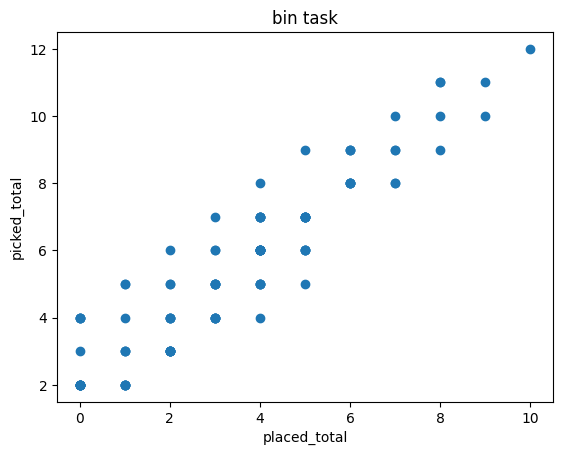

In [114]:
# sanity check
df_bin_sanity = df_bin.copy()
# df_bin.plot()
# df_bin = # df_bin[['picked_total','placed_total','alg','task_level']]
y = df_bin_sanity['picked_total'].values
x = df_bin_sanity['placed_total'].values
plt.scatter(x,y)
plt.xlabel('placed_total')
plt.ylabel('picked_total')
plt.title('bin task')
plt.show()

/tmp/ipykernel_106119/2822901671.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(algs))
/tmp/ipykernel_106119/2822901671.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


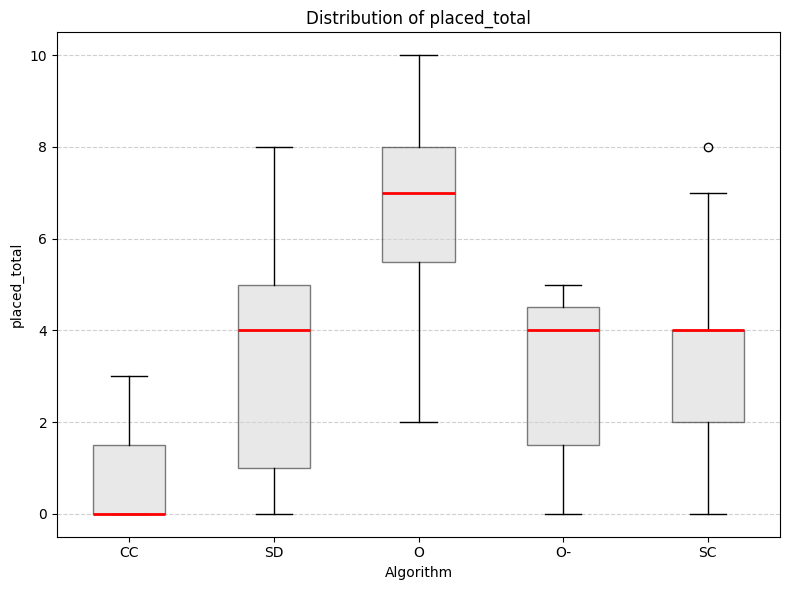

In [115]:
# df_bin_algs = df_bin.groupby('alg')
#df_bin_algs.plot()
def compare_algs_in_bin_task(df,share_y=True,y='placed_total',boxplot=True):
    df_plot = df.copy()
    algs = df_plot["alg"].unique()
    target_col_name = y
    fig, ax = plt.subplots(figsize=(8, 6))

    # Assign colors to algorithms
    colors = plt.cm.get_cmap("tab10", len(algs))
    alg_color_map = {alg: colors(i) for i, alg in enumerate(algs)}

    if not boxplot:
        for i, alg in enumerate(algs):
            sdf = df_plot[df_plot["alg"] == alg]
            ax.scatter(
                [i+1] * len(sdf),  # x coordinate = index of algorithm
                sdf[target_col_name],
                color=alg_color_map[alg],
                alpha=0.7,
                label=alg
            )
    else:
        # Boxplot
        data = [df_plot[df_plot["alg"] == alg][target_col_name] for alg in algs]
        ax.boxplot(
            data, labels=algs,
            patch_artist=True,
            boxprops=dict(facecolor="lightgray", alpha=0.5),
            medianprops=dict(color="red", linewidth=2), # median line in red,
            showfliers=True # show outliers (points outside the whiskers)
        )
        # Color box outlines per algorithm
        for patch, alg in zip(ax.artists, algs):
            patch.set_facecolor(alg_color_map[alg])

    ax.set_xticks(range(1,len(algs)+1))
    ax.set_xticklabels(algs)
    ax.set_xlabel("Algorithm")
    ax.set_ylabel(y)
    ax.set_title("Distribution of " + y)
    ax.grid(True, axis="y", linestyle="--", alpha=0.6)

    if not boxplot:
        # Only add legend for scatter mode (boxplot already labeled by xticks)
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, title="Algorithm")

    plt.tight_layout()
    plt.show()
try:
    compare_algs_in_bin_task(df_bin)
except Exception as e:
    print(f'Error: {e}')

# Analyze Safety

In [ ]:
def analyze_collisions(all_sims):
    """
    Analyze collision data from simulations and return two dataframes:
    1. df_collisions: Summary statistics per simulation
    2. df_collision_extended: Detailed step-by-step collision data
    """
    
    def check_rrc_rre_for_agent(df):
        w_steps_in_rrc = set()
        w_steps_in_rre = set()
        agent_world_col_world_steps = df[df.env_cols == True]['w_step']
        agent_arm_col_world_steps = df[df.arm_cols == True]['w_step']

        for w_step in agent_world_col_world_steps:
            w_steps_in_rrc.add(w_step)
        for w_step in agent_arm_col_world_steps:
            w_steps_in_rre.add(w_step)

        return w_steps_in_rrc, w_steps_in_rre

    # Define columns for df_collisions
    columns = ['alg', 'n_arms', 
    'wstep_total', 'task_type', 
    'task_level', 
    'rre_n', # sum over all robots and all steps of I(i,j) where I(i,t) is 1 if robot i is in collision with environment at step t  
    'rrc_n', #  sum over all robots and all steps of I(i,j) where I(i,t) is 1 if robot i is in collision with another robot at time t 
    'rrc_chance', 
    'rre_chance', 
    'task_seed',
    'sim_id']
    
    rows = []
    extended_rows = []
    successfull_parsing = []
    unsuccessfull_parsing = []
    
    for sim in all_sims:
        try:
            centralized = sim.is_centralized()
            agents_dfs = sim.get_agents_dfs()
            sim_id = sim.meta_data['timestamp']
            
            if centralized:
                df = sim.get_agents_dfs()[0]
                n_steps = df.w_step.max()
                rre_cols, rrc_cols = check_rrc_rre_for_agent(df)
                rre_n = len(rre_cols)
                rrc_n = len(rrc_cols)
                # print('rrc_n:', rrc_n)
                # print('rre_n:', rre_n)
                
                # Create extended rows for centralized case
                for _, row in df.iterrows():
                    extended_rows.append([
                        sim_id,
                        row['w_step'],
                        row['env_cols'] == True if pd.notna(row['env_cols']) else False,
                        row['arm_cols'] == True if pd.notna(row['arm_cols']) else False
                    ])
                    
            else:
                # list of dfs one for each agent (arm)
                w_steps_in_rrc = set()
                w_steps_in_rre = set()
                n_steps = 0    
                for df in agents_dfs:
                    rre_n, rrc_n = check_rrc_rre_for_agent(df)
                    w_steps_in_rrc = set.union(w_steps_in_rrc, rrc_n)
                    w_steps_in_rre = set.union(w_steps_in_rre, rre_n)
                    n_steps = max(n_steps, df.w_step.max())
                    
                    # Create extended rows for decentralized case
                    for _, row in df.iterrows():
                        extended_rows.append([
                            sim_id,
                            row['w_step'],
                            row['env_cols'] == True if pd.notna(row['env_cols']) else False,
                            row['arm_cols'] == True if pd.notna(row['arm_cols']) else False
                        ])
                        
                rre_n = len(w_steps_in_rre)
                rrc_n = len(w_steps_in_rrc)

            rre_chance = rre_n / n_steps
            rrc_chance = rrc_n / n_steps
            rows.append([sim.meta_data['alg'], sim.meta_data['n_arms'], n_steps, sim.meta_data['task_type'],sim.meta_data['task_level'], rre_n, rrc_n, rrc_chance, rre_chance,sim.meta_data['task_seed'], sim.meta_data['timestamp']])
            successfull_parsing.append(sim)

        except Exception as e:
            unsuccessfull_parsing.append((sim,e))

    parsing_summary(successfull_parsing, unsuccessfull_parsing)

    # Create dataframes
    df_collisions = pd.DataFrame(rows, columns=columns)
    df_collision_extended = pd.DataFrame(extended_rows, columns=['sim_id', 'w_step', 'in_rec', 'in_rrc'])
    
    return df_collisions, df_collision_extended

# Run the analysis
all_sims = bin_sims + reach_sims + follow_sims
df_collisions, df_collision_extended = analyze_collisions(all_sims)


rrc_n: 0
rre_n: 0
rrc_n: 0
rre_n: 0
rrc_n: 0
rre_n: 0
rrc_n: 0
rre_n: 0
rrc_n: 0
rre_n: 0
rrc_n: 0
rre_n: 0
rrc_n: 0
rre_n: 0
rrc_n: 0
rre_n: 0
rrc_n: 0
rre_n: 0
rrc_n: 0
rre_n: 0
rrc_n: 0
rre_n: 0
rrc_n: 0
rre_n: 0
rrc_n: 0
rre_n: 0
rrc_n: 0
rre_n: 0
rrc_n: 0
rre_n: 0
rrc_n: 62
rre_n: 14
rrc_n: 78
rre_n: 0
rrc_n: 14
rre_n: 0
rrc_n: 0
rre_n: 56
rrc_n: 0
rre_n: 0
rrc_n: 6
rre_n: 0
rrc_n: 40
rre_n: 0
rrc_n: 72
rre_n: 0
rrc_n: 6
rre_n: 0
rrc_n: 0
rre_n: 0
rrc_n: 76
rre_n: 0
rrc_n: 88
rre_n: 0
rrc_n: 4
rre_n: 24
rrc_n: 42
rre_n: 64
rrc_n: 0
rre_n: 158
rrc_n: 10
rre_n: 78
rrc_n: 76
rre_n: 0
rrc_n: 54
rre_n: 0
rrc_n: 38
rre_n: 0
rrc_n: 16
rre_n: 0
rrc_n: 0
rre_n: 0
rrc_n: 0
rre_n: 0
rrc_n: 0
rre_n: 44
rrc_n: 0
rre_n: 0
rrc_n: 36
rre_n: 2
rrc_n: 98
rre_n: 0
rrc_n: 100
rre_n: 0
rrc_n: 0
rre_n: 0
rrc_n: 0
rre_n: 0
rrc_n: 0
rre_n: 2
rrc_n: 56
rre_n: 0
rrc_n: 36
rre_n: 0
rrc_n: 0
rre_n: 0
rrc_n: 32
rre_n: 0
rrc_n: 26
rre_n: 0
rrc_n: 14
rre_n: 58
rrc_n: 0
rre_n: 0
rrc_n: 0
rre_n: 32
rrc_n: 28
rre_

,alg,n_arms,wstep_total,task_type,task_level,rre_n,rrc_n,rrc_chance,rre_chance,task_seed,sim_id
0,CC,4,500,bin,3,0,0,0.000,0.000,0,2025-08-18_14:53:53
1,CC,4,499,bin,2,0,0,0.000,0.000,2,2025-08-18_14:52:59
2,CC,4,500,bin,4,0,0,0.000,0.000,1,2025-08-18_15:20:00
3,CC,4,500,bin,5,0,0,0.000,0.000,1,2025-08-18_15:22:39
4,CC,4,500,bin,5,0,0,0.000,0.000,0,2025-08-18_15:21:46
...,...,...,...,...,...,...,...,...,...,...,...
354,SC,4,500,follow,4,0,0,0.000,0.000,1,2025-09-01_16:04:35
355,SC,4,500,follow,5,168,0,0.000,0.336,2,2025-09-01_16:13:32
356,SC,4,500,follow,2,0,0,0.000,0.000,0,2025-09-01_15:51:50
357,SC,4,500,follow,1,0,0,0.000,0.000,0,2025-09-01_15:46:21


In [ ]:
df_collisions # high level (contain data at the simulation level, each row is a simulation)

,alg,n_arms,wstep_total,task_type,task_level,rre_n,rrc_n,rrc_chance,rre_chance,task_seed,sim_id
0,CC,4,500,bin,3,0,0,0.000,0.000,0,2025-08-18_14:53:53
1,CC,4,499,bin,2,0,0,0.000,0.000,2,2025-08-18_14:52:59
2,CC,4,500,bin,4,0,0,0.000,0.000,1,2025-08-18_15:20:00
3,CC,4,500,bin,5,0,0,0.000,0.000,1,2025-08-18_15:22:39
4,CC,4,500,bin,5,0,0,0.000,0.000,0,2025-08-18_15:21:46
...,...,...,...,...,...,...,...,...,...,...,...
354,SC,4,500,follow,4,0,0,0.000,0.000,1,2025-09-01_16:04:35
355,SC,4,500,follow,5,168,0,0.000,0.336,2,2025-09-01_16:13:32
356,SC,4,500,follow,2,0,0,0.000,0.000,0,2025-09-01_15:51:50
357,SC,4,500,follow,1,0,0,0.000,0.000,0,2025-09-01_15:46:21


In [139]:
df_collision_extended # more detaield than df_collisios. contains data at thet time step level for all sims

,sim_id,w_step,in_rec,in_rrc
0,2025-08-18_14:53:53,0,False,False
1,2025-08-18_14:53:53,1,False,False
2,2025-08-18_14:53:53,2,False,False
3,2025-08-18_14:53:53,3,False,False
4,2025-08-18_14:53:53,4,False,False
...,...,...,...,...
1802986,2025-09-01_16:08:47,100,False,False
1802987,2025-09-01_16:08:47,200,False,False
1802988,2025-09-01_16:08:47,300,False,False
1802989,2025-09-01_16:08:47,400,False,False


In [ ]:
def get_sims_with_collisions(df_collision_extended):
    return df_collision_extended[df_collision_extended['in_rec'].isin([True]) | df_collision_extended['in_rrc'].isin([True])]['sim_id'].unique()

def keep_only_collision_steps(df_collision_extended):
    return df_collision_extended[df_collision_extended['in_rec'].isin([True]) | df_collision_extended['in_rrc'].isin([True])]

df_collision_extended_cols_only = keep_only_collision_steps(df_collision_extended)


In [152]:
df_collision_extended_cols_only

,sim_id,w_step,in_rec,in_rrc
29879,2025-08-20_19:23:07,76,False,True
29880,2025-08-20_19:23:07,77,False,True
29881,2025-08-20_19:23:07,78,False,True
29882,2025-08-20_19:23:07,79,False,True
29883,2025-08-20_19:23:07,80,False,True
...,...,...,...,...
1802387,2025-09-01_16:08:47,402,False,True
1802388,2025-09-01_16:08:47,403,False,True
1802389,2025-09-01_16:08:47,404,False,True
1802390,2025-09-01_16:08:47,405,False,True


In [156]:
print(f'Sims with collisions: {len(get_sims_with_collisions(df_collision_extended))}')
print('IDs:')
get_sims_with_collisions(df_collision_extended)



Sims with collisions: 158
IDs:


array(['2025-08-20_19:23:07', '2025-08-20_19:59:01',
       '2025-08-20_19:29:36', '2025-08-20_19:53:01',
       '2025-08-20_20:05:35', '2025-08-20_19:17:10',
       '2025-08-20_19:11:13', '2025-09-01_21:44:27',
       '2025-09-01_22:03:52', '2025-09-01_22:07:50',
       '2025-09-01_21:48:04', '2025-09-01_22:13:23',
       '2025-09-01_22:00:11', '2025-08-20_22:22:24',
       '2025-08-20_22:05:54', '2025-08-20_22:38:32',
       '2025-08-20_22:50:02', '2025-08-20_23:01:41',
       '2025-08-20_22:11:01', '2025-08-20_22:56:11',
       '2025-08-20_22:16:40', '2025-09-02_20:00:50',
       '2025-09-02_19:53:04', '2025-09-02_19:56:52',
       '2025-09-02_19:45:06', '2025-09-02_19:54:56',
       '2025-09-02_20:03:09', '2025-09-02_20:07:19',
       '2025-09-02_19:40:47', '2025-09-02_19:47:37',
       '2025-09-02_20:05:09', '2025-09-02_19:34:21',
       '2025-09-02_19:51:01', '2025-09-02_19:42:42',
       '2025-09-02_19:48:46', '2025-09-02_20:01:18',
       '2025-09-02_19:46:44', '2025-09-02_19:5

In [141]:
def create_collision_intervals(df_collision_extended):
    """
    Create collision intervals from the extended collision dataframe.
    
    Args:
        df_collision_extended: DataFrame with columns ['sim_id', 'w_step', 'in_rec', 'in_rrc']
    
    Returns:
        DataFrame with columns ['sim_id', 'col_interval_start_time', 'col_interval_end_time']
    """
    intervals = []
    
    # Group by simulation ID
    for sim_id, group in df_collision_extended.groupby('sim_id'):
        # Sort by w_step to ensure proper ordering
        group = group.sort_values('w_step').reset_index(drop=True)
        
        # Create a combined collision column (True if either in_rec or in_rrc is True)
        group['in_collision'] = group['in_rec'] | group['in_rrc']
        
        # Find collision intervals
        in_interval = False
        interval_start = None
        
        for i, row in group.iterrows():
            if row['in_collision'] and not in_interval:
                # Start of new collision interval
                interval_start = row['w_step']
                in_interval = True
            elif not row['in_collision'] and in_interval:
                # End of collision interval - find the previous step
                if i > 0:
                    prev_step = group.iloc[i-1]['w_step']
                    intervals.append({
                        'sim_id': sim_id,
                        'col_interval_start_time': interval_start,
                        'col_interval_end_time': prev_step
                    })
                in_interval = False
                interval_start = None
        
        # Handle case where collision interval extends to the end of simulation
        if in_interval and interval_start is not None:
            intervals.append({
                'sim_id': sim_id,
                'col_interval_start_time': interval_start,
                'col_interval_end_time': group['w_step'].max()
            })
    
    return pd.DataFrame(intervals)

df_col_intervals = create_collision_intervals(df_collision_history_col_only)
df_col_intervals

,sim_id,col_interval_start_time,col_interval_end_time
0,2025-08-18_11:31:20,275,306
1,2025-08-18_11:34:17,135,498
2,2025-08-18_11:35:18,141,488
3,2025-08-18_11:36:16,337,342
4,2025-08-18_11:37:14,151,482
...,...,...,...
153,2025-09-03_16:43:50,73,467
154,2025-09-03_16:47:32,36,406
155,2025-09-03_16:49:44,31,327
156,2025-09-03_16:54:45,31,327


In [143]:
def count_col_intervals_by_sim(df_collisions_extended):
    df_col_intervals = create_collision_intervals(df_collisions_extended)
    time_intervals_of_col_per_sim = df_col_intervals.groupby('sim_id')['col_interval_end_time'].nunique()
    return time_intervals_of_col_per_sim

df_col_inervals_count = count_col_intervals_by_sim(df_collision_history_col_only)

In [145]:
df_col_inervals_count.describe()

count    158.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: col_interval_end_time, dtype: float64

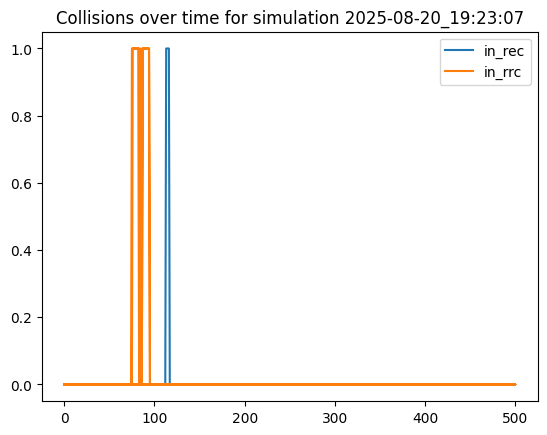

In [158]:
def show_collisions_over_time(df_collisions_extended,sim_id):
    df = df_collisions_extended[df_collisions_extended['sim_id'] == sim_id]
    plt.plot(df['w_step'], df['in_rec'], label='in_rec')
    plt.plot(df['w_step'], df['in_rrc'], label='in_rrc')
    plt.legend()
    plt.title(f'Collisions over time for simulation {sim_id}')
    plt.show()

def get_first_sim_id_with_collision(df_collisions_extended):
    for sim_id in df_collisions_extended['sim_id'].unique():
        df = df_collisions_extended[df_collisions_extended['sim_id'] == sim_id]
        if df['in_rec'].isin([True]).any() or df['in_rrc'].isin([True]).any():
            return sim_id
    return None

# Display the first simulation with collisions

show_collisions_over_time(df_collision_extended,get_first_sim_id_with_collision(df_collision_extended))

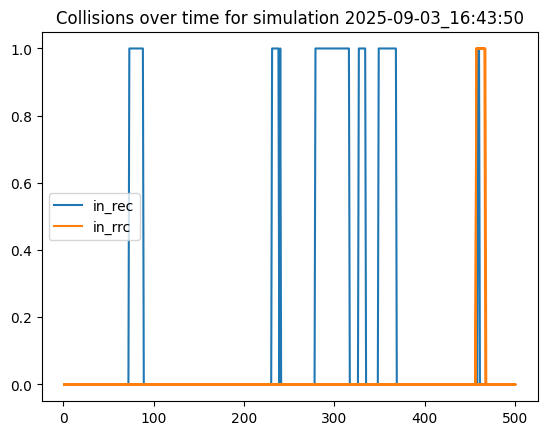

In [160]:
try:
    show_collisions_over_time(df_collision_extended,'2025-09-03_16:43:50')
except Exception as e:
    print(e)

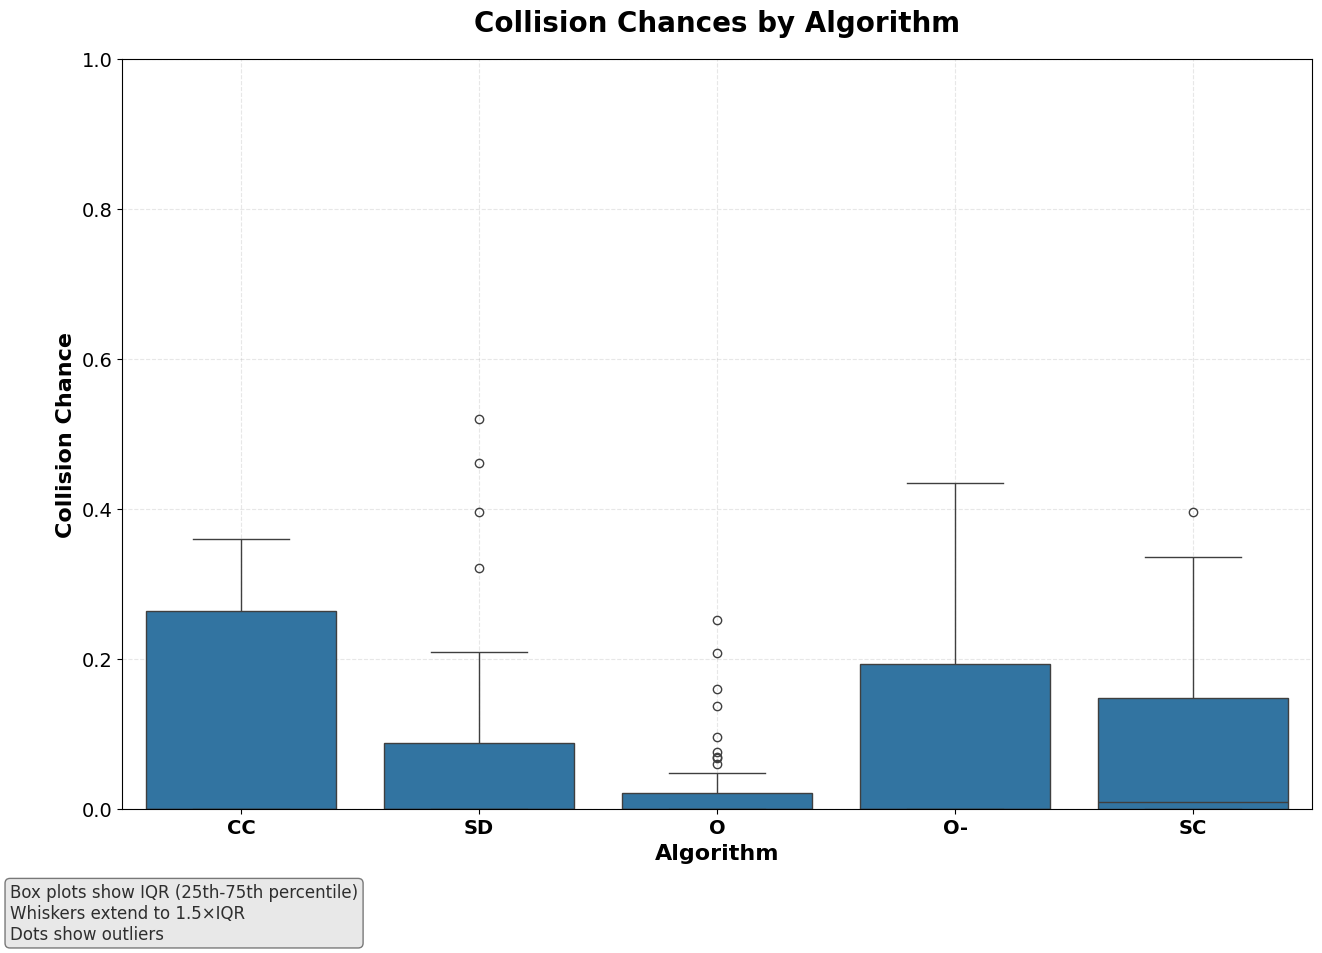


Summary Statistics by Algorithm:
     count    mean     std  min    max  q25   q50    q75
alg                                                     
CC      60  0.0970  0.1429  0.0  0.360  0.0  0.00  0.264
O       60  0.0237  0.0510  0.0  0.252  0.0  0.00  0.022
O-      60  0.0907  0.1240  0.0  0.434  0.0  0.00  0.193
SC     119  0.0766  0.1025  0.0  0.396  0.0  0.01  0.148
SD      60  0.0611  0.1155  0.0  0.520  0.0  0.00  0.088


,sim_id,alg,col_chance
0,2025-08-18_14:53:53,CC,0.000
1,2025-08-18_14:52:59,CC,0.000
2,2025-08-18_15:20:00,CC,0.000
3,2025-08-18_15:22:39,CC,0.000
4,2025-08-18_15:21:46,CC,0.000
...,...,...,...
354,2025-09-01_16:04:35,SC,0.000
355,2025-09-01_16:13:32,SC,0.336
356,2025-09-01_15:51:50,SC,0.000
357,2025-09-01_15:46:21,SC,0.000


In [169]:
def analyze_and_plot_collision_chances(df_collisions):
    """
    Complete analysis and plotting of collision chances by algorithm.
    
    Args:
        df_collisions: DataFrame with collision summary statistics
    
    Returns:
        DataFrame with sim_id, alg, and col_chance columns
    """
    # Create a copy to avoid modifying original
    df_analysis = df_collisions.copy()
    
    # Calculate collision chance as min(1, rrc_chance + rre_chance)
    df_analysis['col_chance'] = df_analysis.apply(
        lambda row: min(1.0, row['rrc_chance'] + row['rre_chance']), axis=1
    )
    
    # Create the result dataframe with required columns
    result_df = df_analysis[['sim_id', 'alg', 'col_chance']].copy()
    
    # Create the plot with better proportions
    plt.figure(figsize=(14, 10))
    
    # Create box plot
    sns.boxplot(data=result_df, x='alg', y='col_chance')
    
    # Customize the plot with larger fonts and better spacing
    plt.title('Collision Chances by Algorithm', fontsize=20, fontweight='bold', pad=20)
    plt.xlabel('Algorithm', fontsize=16, fontweight='bold')
    plt.ylabel('Collision Chance', fontsize=16, fontweight='bold')
    plt.ylim(0, 1)
    
    # Increase tick label sizes
    plt.xticks(fontsize=14, fontweight='bold')
    plt.yticks(fontsize=14)
    
    # Add grid for better readability
    plt.grid(True, alpha=0.3, linestyle='--')
    
    # Add statistics text in a better position
    stats_text = "Box plots show IQR (25th-75th percentile)\nWhiskers extend to 1.5×IQR\nDots show outliers"
    plt.figtext(0.02, 0.02, stats_text, fontsize=12, alpha=0.8, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.5))
    
    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15, left=0.1, right=0.95, top=0.9)
    
    plt.show()
    
    # Print summary statistics
    print("\nSummary Statistics by Algorithm:")
    print("=" * 60)
    summary_stats = result_df.groupby('alg')['col_chance'].agg([
        'count', 'mean', 'std', 'min', 'max', 
        ('q25', lambda x: x.quantile(0.25)),
        ('q50', lambda x: x.quantile(0.50)),
        ('q75', lambda x: x.quantile(0.75))
    ]).round(4)
    print(summary_stats)
    
    return result_df

# Usage:
# df_collision_chances = analyze_and_plot_collision_chances(df_collisions)

analyze_and_plot_collision_chances(df_collisions)

In [46]:
df_collisions.describe()

,n_arms,wstep_total,task_level,rre_n,rrc_n,rrc_chance,rre_chance,task_seed
count,359.0,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000
mean,4.0,499.997214,4.041783,24.077994,11.392758,0.022786,0.048156,1.002786
std,0.0,0.052778,2.481424,48.146942,26.226965,0.052454,0.096294,0.817062
min,4.0,499.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.0,500.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.0,500.000000,4.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,4.0,500.000000,5.000000,20.000000,5.000000,0.010000,0.040000,2.000000
max,4.0,500.000000,10.000000,240.000000,137.000000,0.274000,0.480000,2.000000


In [47]:
def compare_algs_safety(df_collisions,share_y=True,boxplot=False,chance=True):
    df_plot = df_collisions.copy()
    algs = df_plot["alg"].unique()
    
    
    if chance:
        y1 = 'rrc_chance'
        y2 = 'rre_chance'
    else:
        y1 = 'rrc_n'
        y2 = 'rre_n'
        
    fig, ax = plt.subplots(figsize=(8, 6))

    # Assign colors to algorithms
    colors = plt.cm.get_cmap("tab10", len(algs))
    alg_color_map = {alg: colors(i) for i, alg in enumerate(algs)}

    if not boxplot:
        for i, alg in enumerate(algs):
            sdf = df_plot[df_plot["alg"] == alg]
            ax.scatter(
                [i+1] * len(sdf),  # x coordinate = index of algorithm
                sdf[y1],
                color=alg_color_map[alg],
                alpha=0.7,
                label=alg
            )
            ax.scatter(
                [i+1] * len(sdf),  # x coordinate = index of algorithm
                sdf[y2],
                color=alg_color_map[alg],
                alpha=0.7,
                label=alg
            )
    else:
        # Boxplot
        data = [df_plot[df_plot["alg"] == alg][[y1,y2]] for alg in algs]
        data1 = [df_plot[df_plot["alg"] == alg][y1] for alg in algs]
        data2 = [df_plot[df_plot["alg"] == alg][y2] for alg in algs]
        ax.boxplot(
            data1, 
            labels=algs,
            patch_artist=True,
            boxprops=dict(facecolor="lightgray", alpha=0.5),
            medianprops=dict(color="red", linewidth=2), # median line in red,
            showfliers=True # show outliers (points outside the whiskers)
        )
        # Color box outlines per algorithm
        for patch, alg in zip(ax.artists, algs):
            patch.set_facecolor(alg_color_map[alg])


    ax.set_xticks(range(1,len(algs)+1))
    ax.set_xticklabels(algs)
    ax.set_xlabel("Algorithm")
    ax.set_ylabel(y)
    # ax.set_title("Distribution of " + y)
    ax.grid(True, axis="y", linestyle="--", alpha=0.6)

    if not boxplot:
        # Only add legend for scatter mode (boxplot already labeled by xticks)
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, title="Algorithm")

    plt.tight_layout()
    plt.show()

if not O_tuning:
    compare_algs_safety(df_collisions)


In [48]:
df_collisions

,alg,n_arms,wstep_total,task_type,task_level,rre_n,rrc_n,rrc_chance,rre_chance,task_seed,sim_id
0,CC,4,500,bin,3,0,0,0.000,0.000,0,2025-08-18_14:53:53
1,CC,4,499,bin,2,0,0,0.000,0.000,2,2025-08-18_14:52:59
2,CC,4,500,bin,4,0,0,0.000,0.000,1,2025-08-18_15:20:00
3,CC,4,500,bin,5,0,0,0.000,0.000,1,2025-08-18_15:22:39
4,CC,4,500,bin,5,0,0,0.000,0.000,0,2025-08-18_15:21:46
...,...,...,...,...,...,...,...,...,...,...,...
354,SC,4,500,follow,4,0,0,0.000,0.000,1,2025-09-01_16:04:35
355,SC,4,500,follow,5,168,0,0.000,0.336,2,2025-09-01_16:13:32
356,SC,4,500,follow,2,0,0,0.000,0.000,0,2025-09-01_15:51:50
357,SC,4,500,follow,1,0,0,0.000,0.000,0,2025-09-01_15:46:21


In [49]:
df_reach

,alg,task_level,task_seed,n_arms,wsteps_total,sim_id,reached_total,changed_total
0,CC,10,0,4,500,2025-09-03_16:49:44,0,16
1,CC,4,2,4,500,2025-09-03_15:16:46,2,17
2,CC,2,2,4,500,2025-09-03_14:59:37,2,17
3,CC,10,2,4,500,2025-09-03_16:57:45,0,16
4,CC,6,1,4,500,2025-09-03_15:35:53,0,16
...,...,...,...,...,...,...,...,...
145,SC,10,0,4,500,2025-09-03_16:02:39,0,16
146,SC,4,1,4,500,2025-09-03_15:27:23,8,19
147,SC,3,0,4,500,2025-09-03_15:18:45,12,22
148,SC,7,2,4,500,2025-09-03_15:48:26,5,17


In [50]:
def make_overall_df(df_collisions,successfull_parsing,colfree_only=False):
    """
    Make a dataframe with all the data from the experiments.
    The dataframe contains the following columns:
    - sim_id: the id of the simulation
    - alg: the algorithm used
    - task_type: the type of task
    - task_level: the level of the task
    - task_seed: the seed of the task
    - task_score_reach: the score of the reach task or 0 if the task is not a reach task
    - task_score_bin: the score of the bin task or 0 if the task is not a bin task
    - task_score_follow: the score of the follow task or 0 if the task is not a follow task
    
    - safety_score_rrc: the score of the rrc safety metric (1 - (N collisions / N world steps total))
    - safety_score_rec: the score of the rec safety metric (1 - (N collisions / N world steps total))
    - task_score: the score of the task (sum of task_score_reach, task_score_bin, task_score_follow). Only the task score is considered (the other 2 tasks are 0)
    - overall_score: the overall score (task_score * score_weights_TER[0] + safety_score_rec * score_weights_TER[1] + safety_score_rrc * score_weights_TER[2])
    
    
    """
    import yaml
    overall_df = df_collisions.copy()
    overall_df[['weight','trust','cov']] = -1,-1,-1 # add columns for tuning
    for sim in successfull_parsing:
        sim_id = sim.meta_data['timestamp']
        all_sims = sim_paths
        for dir_path in all_sims:
            if sim_id in dir_path:
                
                # Add meta data and task specific columns
                overall_df.loc[overall_df['sim_id'] == sim_id, 'alg'] = sim.meta_data['alg']
                overall_df.loc[overall_df['sim_id'] == sim_id, 'task_type'] = sim.meta_data['task_type']
                overall_df.loc[overall_df['sim_id'] == sim_id, 'task_level'] = sim.meta_data['task_level']
                overall_df.loc[overall_df['sim_id'] == sim_id, 'task_seed'] = sim.meta_data['task_seed']
                
                task_type = sim.meta_data['task_type']
                if task_type == 'reach':
                    
                    
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'changed_total'] = \
                          df_reach[df_reach['sim_id'] == sim_id]['changed_total'].values[0]
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'reached_total'] =\
                        df_reach[df_reach['sim_id'] == sim_id]['reached_total'].values[0]

                    
                elif task_type == 'follow':
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'p_err_mean_arms_wsteps'] = \
                        df_follow[df_follow['sim_id'] == sim_id]['p_err_mean'].mean() # taking the mean over arms and making a mean over w_steps
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'p_err_var_arms_wsteps'] = \
                        df_follow[df_follow['sim_id'] == sim_id]['p_err_var'].mean() # taking the var over arms and making a mean over w_steps
                elif task_type == 'bin':
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'picked_total'] = \
                        df_bin[df_bin['sim_id'] == sim_id]['picked_total'].values[0]
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'placed_total'] = \
                        df_bin[df_bin['sim_id'] == sim_id]['placed_total'].values[0]
                    

                else:
                    raise ValueError(f'Task type {sim.meta_data["task_type"]} not supported')
                
                # Add tuning parameters if they exist
                tuning_path = os.path.join(dir_path, 'particle_cfg.yml')
                if not os.path.exists(tuning_path):
                    continue
                with open(tuning_path, 'r') as f:
                    particle_cfg = yaml.load(f, Loader=yaml.FullLoader)
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'weight'] = particle_cfg['cost']['custom']['arm_base']['dynamic_obs_cost']['weight']
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'trust'] = particle_cfg['cost']['custom']['arm_base']['dynamic_obs_cost']['wta_trust']
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'cov'] = particle_cfg['mppi']['init_cov']
        

    try:
        overall_df['task_score_reach'] = overall_df['reached_total'] / overall_df['reached_total'].max()
    except:
        overall_df['task_score_reach'] = 0
    try:
        overall_df['task_score_bin'] = overall_df['placed_total']  / overall_df['placed_total'].max()
    except:
        overall_df['task_score_bin'] = 0

    try:
        normalized_sim_follow_mean_error =  (overall_df['p_err_mean_arms_wsteps'] - overall_df['p_err_mean_arms_wsteps'].min()) / (overall_df['p_err_mean_arms_wsteps'].max() - overall_df['p_err_mean_arms_wsteps'].min()) 
        overall_df['task_score_follow'] = 1 - normalized_sim_follow_mean_error 
    except:
        overall_df['task_score_follow'] = 0

    overall_df['safety_score_rrc'] = 1 - overall_df['rrc_chance']
    overall_df['safety_score_rec'] = 1 - overall_df['rre_chance']

    if colfree_only: # only keep colfree simulations
        overall_df = overall_df[(overall_df['rrc_chance'] == 0.0) & (overall_df['rre_chance'] == 0.0)]
    
    # Fill NaNs with 0 at the tasks which are not run
    overall_df[['task_score_reach','task_score_bin','task_score_follow']] = \
        overall_df[['task_score_reach','task_score_bin','task_score_follow']].fillna(0) 
    
    overall_df['task_score'] = overall_df[['task_score_reach','task_score_bin','task_score_follow']].sum(axis=1) # just the task score (other 2 tasks are 0)
    return overall_df


In [51]:
overall_df = make_overall_df(df_collisions,
                             successfull_parsing,
                             colfree_only=False,
                             )


/tmp/ipykernel_106119/2008806385.py:69: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.05' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  overall_df.loc[overall_df['sim_id'] == sim_id, 'cov'] = particle_cfg['mppi']['init_cov']


In [52]:
overall_df.describe()

,n_arms,wstep_total,task_level,rre_n,rrc_n,rrc_chance,rre_chance,task_seed,weight,trust,...,changed_total,reached_total,p_err_mean_arms_wsteps,p_err_var_arms_wsteps,task_score_reach,task_score_bin,task_score_follow,safety_score_rrc,safety_score_rec,task_score
count,359.0,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,...,150.000000,150.000000,104.000000,104.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000
mean,4.0,499.997214,4.050139,24.077994,11.392758,0.022786,0.048156,1.008357,76030.557103,1.913649,...,23.613333,13.466667,0.147762,0.006386,0.108207,0.101950,0.234985,0.977214,0.951844,0.445142
std,0.0,0.052778,2.494182,48.146942,26.226965,0.052454,0.096294,0.817024,41823.759814,0.954734,...,9.878990,14.883289,0.082606,0.008973,0.224622,0.205161,0.386912,0.052454,0.096294,0.347964
min,4.0,499.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,...,16.000000,0.000000,0.076872,0.001504,0.000000,0.000000,0.000000,0.726000,0.520000,0.000000
25%,4.0,500.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100000.000000,2.000000,...,16.000000,2.000000,0.096283,0.002199,0.000000,0.000000,0.000000,0.990000,0.960000,0.100000
50%,4.0,500.000000,4.000000,0.000000,0.000000,0.000000,0.000000,1.000000,100000.000000,2.000000,...,19.000000,6.500000,0.110696,0.002810,0.000000,0.000000,0.000000,1.000000,1.000000,0.400000
75%,4.0,500.000000,5.000000,20.000000,5.000000,0.010000,0.040000,2.000000,100000.000000,2.000000,...,31.000000,27.000000,0.151788,0.004242,0.076923,0.100000,0.476640,1.000000,1.000000,0.800313
max,4.0,500.000000,10.000000,240.000000,137.000000,0.274000,0.480000,2.000000,100000.000000,3.000000,...,52.000000,52.000000,0.452250,0.054642,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


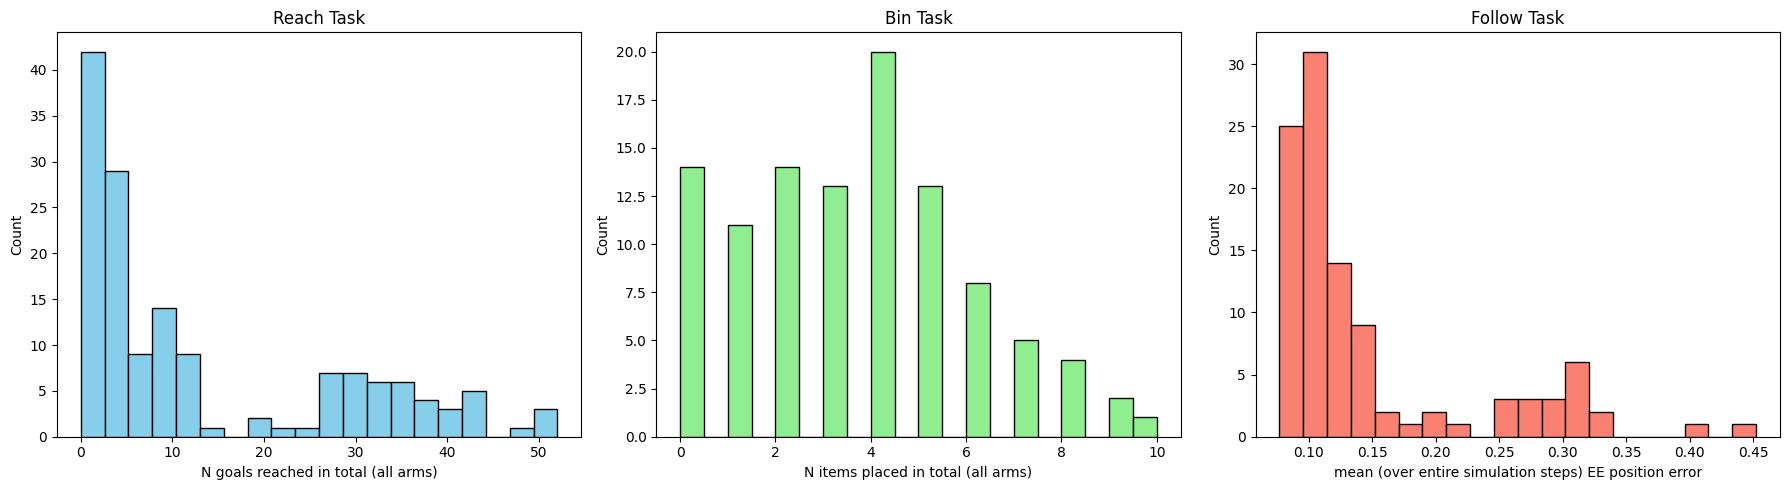

In [53]:
# Histogram of the follow task score
try:
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    # Histogram for task_score_reach
    axs[0].hist(overall_df[overall_df.task_type == 'reach']['reached_total'], bins=20, color='skyblue', edgecolor='black')
    axs[0].set_title('Reach Task')
    axs[0].set_xlabel('N goals reached in total (all arms)')
    axs[0].set_ylabel('Count')

    # Histogram for task_score_bins
    axs[1].hist(overall_df[overall_df.task_type == 'bin']['placed_total'], bins=20, color='lightgreen', edgecolor='black')
    axs[1].set_title('Bin Task')
    axs[1].set_xlabel('N items placed in total (all arms)')
    axs[1].set_ylabel('Count')

    # Histogram for task_score_follow
    axs[2].hist(overall_df[overall_df.task_type == 'follow']['p_err_mean_arms_wsteps'], bins=20, color='salmon', edgecolor='black')
    axs[2].set_title('Follow Task')
    axs[2].set_xlabel('mean (over entire simulation steps) EE position error')
    axs[2].set_ylabel('Count')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f'Error: {e}')
    pass

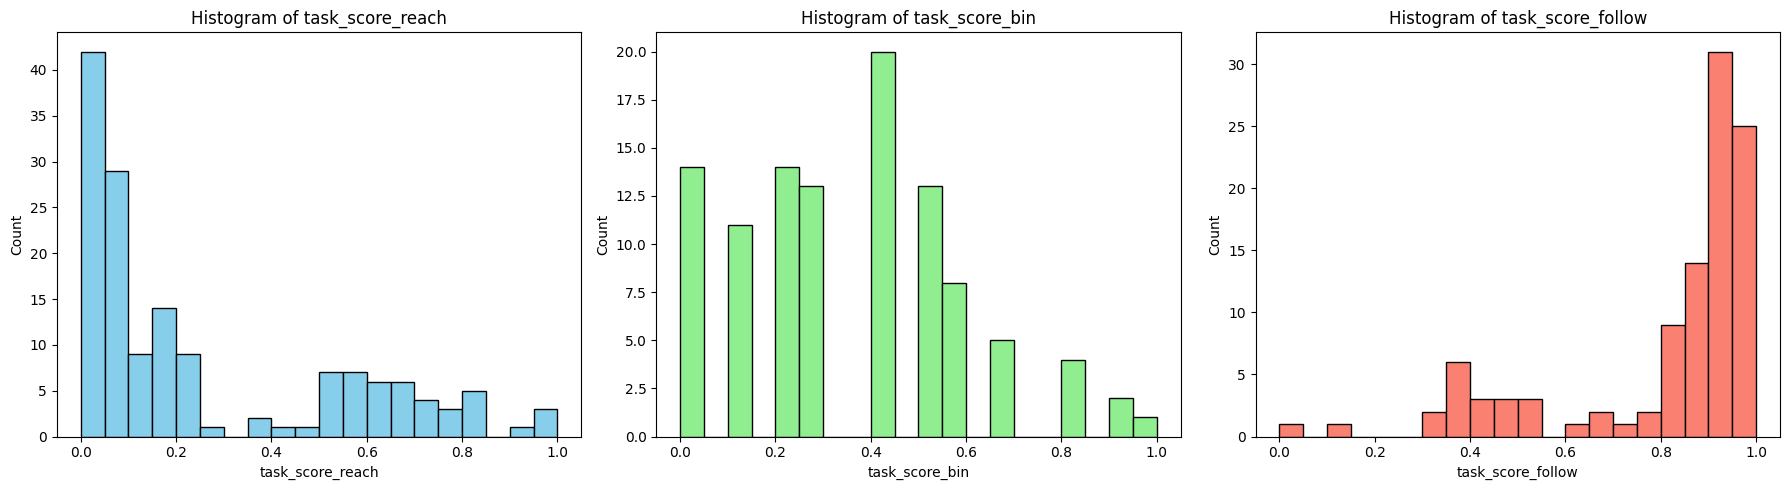

In [54]:
# Histogram of the follow task score
try:
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    # Histogram for task_score_reach
    axs[0].hist(overall_df[overall_df.task_type == 'reach']['task_score_reach'], bins=20, color='skyblue', edgecolor='black')
    axs[0].set_title('Histogram of task_score_reach')
    axs[0].set_xlabel('task_score_reach')
    axs[0].set_ylabel('Count')

    # Histogram for task_score_bin
    axs[1].hist(overall_df[overall_df.task_type == 'bin']['task_score_bin'], bins=20, color='lightgreen', edgecolor='black')
    axs[1].set_title('Histogram of task_score_bin')
    axs[1].set_xlabel('task_score_bin')
    axs[1].set_ylabel('Count')

    # Histogram for task_score_follow
    axs[2].hist(overall_df[overall_df.task_type == 'follow']['task_score_follow'], bins=20, color='salmon', edgecolor='black')
    axs[2].set_title('Histogram of task_score_follow')
    axs[2].set_xlabel('task_score_follow')
    axs[2].set_ylabel('Count')

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Error: {e}')
    pass

/tmp/ipykernel_106119/1950053788.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axs[0].boxplot(reach_alg_data, labels=algorithms, patch_artist=True)
/tmp/ipykernel_106119/1950053788.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axs[1].boxplot(bin_alg_data, labels=algorithms, patch_artist=True)
/tmp/ipykernel_106119/1950053788.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = axs[2].boxplot(follow_alg_data, labels=algorithms, patch_artist=True)


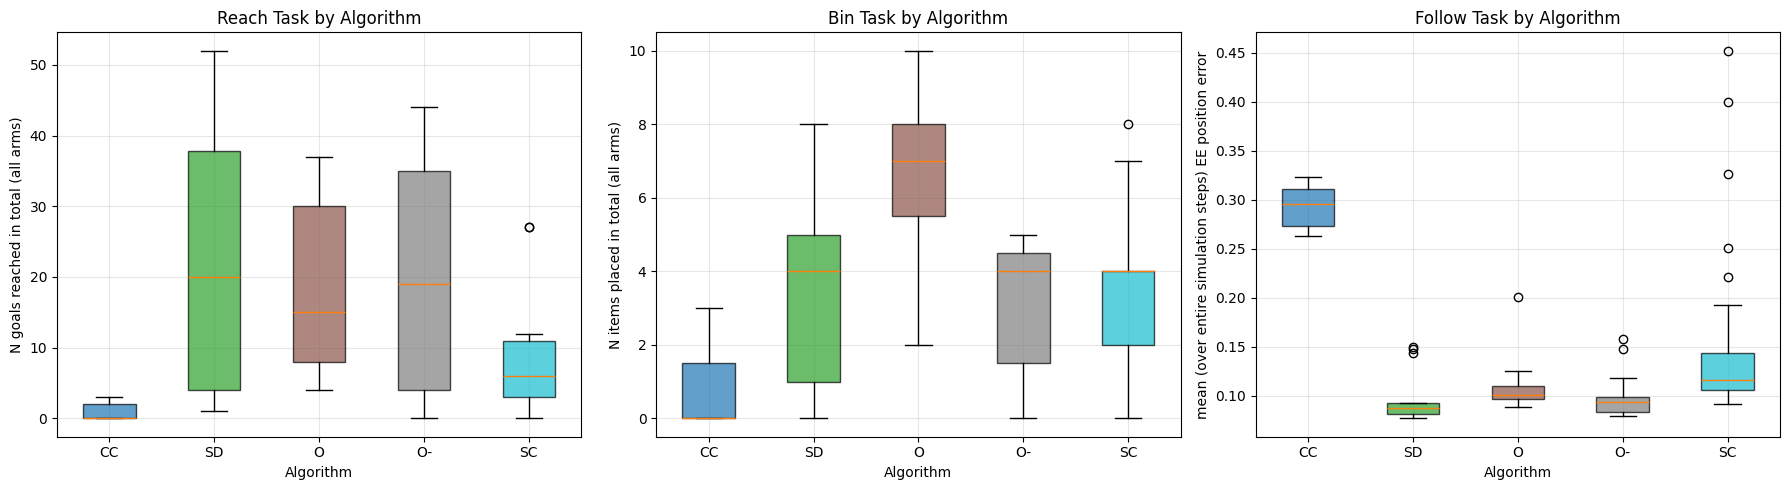

In [55]:
# Second order dissection: Box plots by algorithm for each task
try:
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    # Get unique algorithms and assign colors
    algorithms = overall_df['alg'].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(algorithms)))

    # Box plot for reach task by algorithm
    reach_data = overall_df[overall_df.task_type == 'reach']
    reach_alg_data = [reach_data[reach_data['alg'] == alg]['reached_total'] for alg in algorithms]
    bp1 = axs[0].boxplot(reach_alg_data, labels=algorithms, patch_artist=True)
    for patch, color in zip(bp1['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axs[0].set_title('Reach Task by Algorithm')
    axs[0].set_xlabel('Algorithm')
    axs[0].set_ylabel('N goals reached in total (all arms)')
    axs[0].grid(True, alpha=0.3)

    # Box plot for bin task by algorithm
    bin_data = overall_df[overall_df.task_type == 'bin']
    bin_alg_data = [bin_data[bin_data['alg'] == alg]['placed_total'] for alg in algorithms]
    bp2 = axs[1].boxplot(bin_alg_data, labels=algorithms, patch_artist=True)
    for patch, color in zip(bp2['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axs[1].set_title('Bin Task by Algorithm')
    axs[1].set_xlabel('Algorithm')
    axs[1].set_ylabel('N items placed in total (all arms)')
    axs[1].grid(True, alpha=0.3)

    # Box plot for follow task by algorithm
    follow_data = overall_df[overall_df.task_type == 'follow']
    follow_alg_data = [follow_data[follow_data['alg'] == alg]['p_err_mean_arms_wsteps'] for alg in algorithms]
    bp3 = axs[2].boxplot(follow_alg_data, labels=algorithms, patch_artist=True)
    for patch, color in zip(bp3['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axs[2].set_title('Follow Task by Algorithm')
    axs[2].set_xlabel('Algorithm')
    axs[2].set_ylabel('mean (over entire simulation steps) EE position error')
    axs[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Error: {e}')
    pass

/tmp/ipykernel_106119/2207886811.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs[0].scatter([i+1] * len(no_collision), no_collision['reached_total'],
/tmp/ipykernel_106119/2207886811.py:25: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs[0].scatter([i+1] * len(collision), collision['reached_total'],
/tmp/ipykernel_106119/2207886811.py:47: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, 

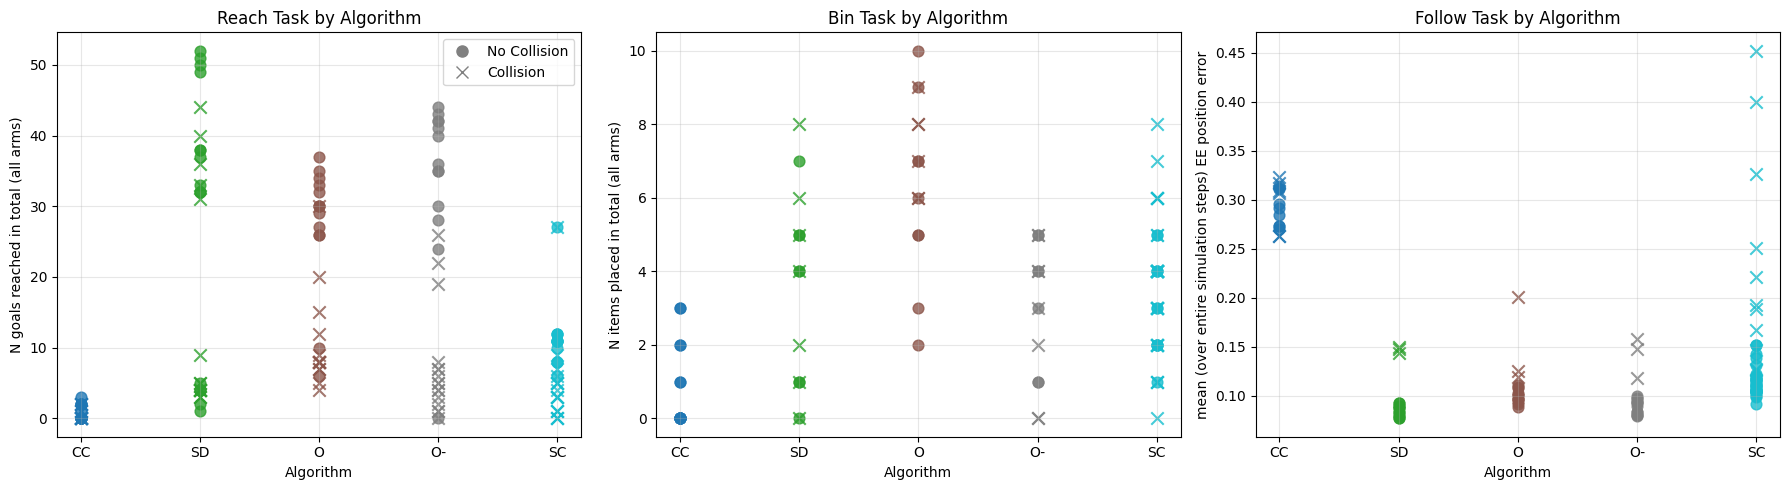

In [56]:
try:
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    # Get unique algorithms and assign colors
    algorithms = overall_df['alg'].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(algorithms)))

    # Scatter plot for reach task by algorithm
    reach_data = overall_df[overall_df.task_type == 'reach']
    for i, alg in enumerate(algorithms):
        alg_data = reach_data[reach_data['alg'] == alg]
        
        # Separate collision vs no collision
        no_collision = alg_data[(alg_data['rrc_chance'] == 0.0) & (alg_data['rre_chance'] == 0.0)]
        collision = alg_data[(alg_data['rrc_chance'] > 0.0) | (alg_data['rre_chance'] > 0.0)]
        
        # Plot no collision as circles
        if len(no_collision) > 0:
            axs[0].scatter([i+1] * len(no_collision), no_collision['reached_total'], 
                        c=colors[i], marker='o', s=60, alpha=0.8, 
                        label=f'{alg} (no collision)' if i == 0 else "")
        
        # Plot collision as X marks
        if len(collision) > 0:
            axs[0].scatter([i+1] * len(collision), collision['reached_total'], 
                        c=colors[i], marker='x', s=80, alpha=0.8, 
                        label=f'{alg} (collision)' if i == 0 else "")

    axs[0].set_title('Reach Task by Algorithm')
    axs[0].set_xlabel('Algorithm')
    axs[0].set_ylabel('N goals reached in total (all arms)')
    axs[0].set_xticks(range(1, len(algorithms)+1))
    axs[0].set_xticklabels(algorithms)
    axs[0].grid(True, alpha=0.3)

    # Scatter plot for bin task by algorithm
    bin_data = overall_df[overall_df.task_type == 'bin']
    for i, alg in enumerate(algorithms):
        alg_data = bin_data[bin_data['alg'] == alg]
        
        # Separate collision vs no collision
        no_collision = alg_data[(alg_data['rrc_chance'] == 0.0) & (alg_data['rre_chance'] == 0.0)]
        collision = alg_data[(alg_data['rrc_chance'] > 0.0) | (alg_data['rre_chance'] > 0.0)]
        
        # Plot no collision as circles
        if len(no_collision) > 0:
            axs[1].scatter([i+1] * len(no_collision), no_collision['placed_total'], 
                        c=colors[i], marker='o', s=60, alpha=0.8)
        
        # Plot collision as X marks
        if len(collision) > 0:
            axs[1].scatter([i+1] * len(collision), collision['placed_total'], 
                        c=colors[i], marker='x', s=80, alpha=0.8)

    axs[1].set_title('Bin Task by Algorithm')
    axs[1].set_xlabel('Algorithm')
    axs[1].set_ylabel('N items placed in total (all arms)')
    axs[1].set_xticks(range(1, len(algorithms)+1))
    axs[1].set_xticklabels(algorithms)
    axs[1].grid(True, alpha=0.3)

    # Scatter plot for follow task by algorithm
    follow_data = overall_df[overall_df.task_type == 'follow']
    for i, alg in enumerate(algorithms):
        alg_data = follow_data[follow_data['alg'] == alg]
        
        # Separate collision vs no collision
        no_collision = alg_data[(alg_data['rrc_chance'] == 0.0) & (alg_data['rre_chance'] == 0.0)]
        collision = alg_data[(alg_data['rrc_chance'] > 0.0) | (alg_data['rre_chance'] > 0.0)]
        
        # Plot no collision as circles
        if len(no_collision) > 0:
            axs[2].scatter([i+1] * len(no_collision), no_collision['p_err_mean_arms_wsteps'], 
                        c=colors[i], marker='o', s=60, alpha=0.8)
        
        # Plot collision as X marks
        if len(collision) > 0:
            axs[2].scatter([i+1] * len(collision), collision['p_err_mean_arms_wsteps'], 
                        c=colors[i], marker='x', s=80, alpha=0.8)

    axs[2].set_title('Follow Task by Algorithm')
    axs[2].set_xlabel('Algorithm')
    axs[2].set_ylabel('mean (over entire simulation steps) EE position error')
    axs[2].set_xticks(range(1, len(algorithms)+1))
    axs[2].set_xticklabels(algorithms)
    axs[2].grid(True, alpha=0.3)

    # Add legend for markers
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='o', color='gray', linestyle='None', 
                            markersize=8, label='No Collision'),
                    Line2D([0], [0], marker='x', color='gray', linestyle='None', 
                            markersize=8, label='Collision')]
    axs[0].legend(handles=legend_elements, loc='upper right')

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Error: {e}')
    pass

In [57]:
def make_overall_df(df_collisions,successfull_parsing,colfree_only=False):
    """
    Make a dataframe with all the data from the experiments.
    The dataframe contains the following columns:
    - sim_id: the id of the simulation
    - alg: the algorithm used
    - task_type: the type of task
    - task_level: the level of the task
    - task_seed: the seed of the task
    - task_score_reach: the score of the reach task or 0 if the task is not a reach task
    - task_score_bin: the score of the bin task or 0 if the task is not a bin task
    - task_score_follow: the score of the follow task or 0 if the task is not a follow task
    
    - safety_score_rrc: the score of the rrc safety metric (1 - (N collisions / N world steps total))
    - safety_score_rec: the score of the rec safety metric (1 - (N collisions / N world steps total))
    - task_score: the score of the task (sum of task_score_reach, task_score_bin, task_score_follow). Only the task score is considered (the other 2 tasks are 0)
    - overall_score: the overall score (task_score * score_weights_TER[0] + safety_score_rec * score_weights_TER[1] + safety_score_rrc * score_weights_TER[2])
    
    
    """
    import yaml
    overall_df = df_collisions.copy()
    overall_df[['weight','trust','cov']] = -1,-1,-1 # add columns for tuning
    for sim in successfull_parsing:
        sim_id = sim.meta_data['timestamp']
        all_sims = sim_paths
        for dir_path in all_sims:
            if sim_id in dir_path:
                
                # Add meta data and task specific columns
                overall_df.loc[overall_df['sim_id'] == sim_id, 'alg'] = sim.meta_data['alg']
                overall_df.loc[overall_df['sim_id'] == sim_id, 'task_type'] = sim.meta_data['task_type']
                overall_df.loc[overall_df['sim_id'] == sim_id, 'task_level'] = sim.meta_data['task_level']
                overall_df.loc[overall_df['sim_id'] == sim_id, 'task_seed'] = sim.meta_data['task_seed']
                
                task_type = sim.meta_data['task_type']
                if task_type == 'reach':
                    
                    # overall_df.loc[overall_df['sim_id'] == sim_id, 'changed_total'] = \
                    #       df_reach[df_reach['sim_id'] == sim_id]['changed_total']
                    # overall_df.loc[overall_df['sim_id'] == sim_id, 'reached_total'] =\
                    #     df_reach[df_reach['sim_id'] == sim_id]['reached_total']

                    overall_df.loc[overall_df['sim_id'] == sim_id, 'changed_total'] = \
                          df_reach[df_reach['sim_id'] == sim_id]['changed_total'].values[0]
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'reached_total'] =\
                        df_reach[df_reach['sim_id'] == sim_id]['reached_total'].values[0]

                    
                elif task_type == 'follow':
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'p_err_mean_arms_wsteps'] = \
                        df_follow[df_follow['sim_id'] == sim_id]['p_err_mean'].mean() # taking the mean over arms and making a mean over w_steps
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'p_err_var_arms_wsteps'] = \
                        df_follow[df_follow['sim_id'] == sim_id]['p_err_var'].mean() # taking the var over arms and making a mean over w_steps
                elif task_type == 'bin':
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'picked_total'] = \
                        df_bin[df_bin['sim_id'] == sim_id]['picked_total'].values[0]
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'placed_total'] = \
                        df_bin[df_bin['sim_id'] == sim_id]['placed_total'].values[0]
                    

                else:
                    raise ValueError(f'Task type {sim.meta_data["task_type"]} not supported')
                
                # Add tuning parameters if they exist
                tuning_path = os.path.join(dir_path, 'particle_cfg.yml')
                if not os.path.exists(tuning_path):
                    continue
                with open(tuning_path, 'r') as f:
                    particle_cfg = yaml.load(f, Loader=yaml.FullLoader)
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'weight'] = particle_cfg['cost']['custom']['arm_base']['dynamic_obs_cost']['weight']
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'trust'] = particle_cfg['cost']['custom']['arm_base']['dynamic_obs_cost']['wta_trust']
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'cov'] = particle_cfg['mppi']['init_cov']
        

    try:
        overall_df['task_score_reach'] = overall_df['reached_total'] / overall_df['reached_total'].max()
    except:
        overall_df['task_score_reach'] = 0
    try:
        overall_df['task_score_bin'] = overall_df['placed_total']  / overall_df['placed_total'].max()
    except:
        overall_df['task_score_bin'] = 0

    try:
        normalized_sim_follow_mean_error =  (overall_df['p_err_mean_arms_wsteps'] - overall_df['p_err_mean_arms_wsteps'].min()) / (overall_df['p_err_mean_arms_wsteps'].max() - overall_df['p_err_mean_arms_wsteps'].min()) 
        overall_df['task_score_follow'] = 1 - normalized_sim_follow_mean_error 
    except:
        overall_df['task_score_follow'] = 0

    overall_df['safety_score_rrc'] = 1 - overall_df['rrc_chance']
    overall_df['safety_score_rec'] = 1 - overall_df['rre_chance']

    if colfree_only: # only keep colfree simulations
        overall_df = overall_df[(overall_df['rrc_chance'] == 0.0) & (overall_df['rre_chance'] == 0.0)]
    
    # Fill NaNs with 0 at the tasks which are not run
    overall_df[['task_score_reach','task_score_bin','task_score_follow']] = \
        overall_df[['task_score_reach','task_score_bin','task_score_follow']].fillna(0) 
    
    overall_df['task_score'] = overall_df[['task_score_reach','task_score_bin','task_score_follow']].sum(axis=1) # just the task score (other 2 tasks are 0)
    return overall_df


In [58]:
def make_overall_df(df_collisions,successfull_parsing,colfree_only=False):
    """
    Make a dataframe with all the data from the experiments.
    The dataframe contains the following columns:
    - sim_id: the id of the simulation
    - alg: the algorithm used
    - task_type: the type of task
    - task_level: the level of the task
    - task_seed: the seed of the task
    - task_score_reach: the score of the reach task or 0 if the task is not a reach task
    - task_score_bin: the score of the bin task or 0 if the task is not a bin task
    - task_score_follow: the score of the follow task or 0 if the task is not a follow task
    
    - safety_score_rrc: the score of the rrc safety metric (1 - (N collisions / N world steps total))
    - safety_score_rec: the score of the rec safety metric (1 - (N collisions / N world steps total))
    - task_score: the score of the task (sum of task_score_reach, task_score_bin, task_score_follow). Only the task score is considered (the other 2 tasks are 0)
    - overall_score: the overall score (task_score * score_weights_TER[0] + safety_score_rec * score_weights_TER[1] + safety_score_rrc * score_weights_TER[2])
    
    
    """
    import yaml
    overall_df = df_collisions.copy()
    overall_df[['weight','trust','cov']] = -1,-1,-1 # add columns for tuning
    for sim in successfull_parsing:
        sim_id = sim.meta_data['timestamp']
        all_sims = sim_paths
        for dir_path in all_sims:
            if sim_id in dir_path:
                
                # Add meta data and task specific columns
                overall_df.loc[overall_df['sim_id'] == sim_id, 'alg'] = sim.meta_data['alg']
                overall_df.loc[overall_df['sim_id'] == sim_id, 'task_type'] = sim.meta_data['task_type']
                overall_df.loc[overall_df['sim_id'] == sim_id, 'task_level'] = sim.meta_data['task_level']
                overall_df.loc[overall_df['sim_id'] == sim_id, 'task_seed'] = sim.meta_data['task_seed']
                
                task_type = sim.meta_data['task_type']
                if task_type == 'reach':
                    
                    # overall_df.loc[overall_df['sim_id'] == sim_id, 'changed_total'] = \
                    #       df_reach[df_reach['sim_id'] == sim_id]['changed_total']
                    # overall_df.loc[overall_df['sim_id'] == sim_id, 'reached_total'] =\
                    #     df_reach[df_reach['sim_id'] == sim_id]['reached_total']

                    overall_df.loc[overall_df['sim_id'] == sim_id, 'changed_total'] = \
                          df_reach[df_reach['sim_id'] == sim_id]['changed_total'].values[0]
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'reached_total'] =\
                        df_reach[df_reach['sim_id'] == sim_id]['reached_total'].values[0]

                    
                elif task_type == 'follow':
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'p_err_mean_arms_wsteps'] = \
                        df_follow[df_follow['sim_id'] == sim_id]['p_err_mean'].mean() # taking the mean over arms and making a mean over w_steps
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'p_err_var_arms_wsteps'] = \
                        df_follow[df_follow['sim_id'] == sim_id]['p_err_var'].mean() # taking the var over arms and making a mean over w_steps
                elif task_type == 'bin':
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'picked_total'] = \
                        df_bin[df_bin['sim_id'] == sim_id]['picked_total'].values[0]
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'placed_total'] = \
                        df_bin[df_bin['sim_id'] == sim_id]['placed_total'].values[0]
                    

                else:
                    raise ValueError(f'Task type {sim.meta_data["task_type"]} not supported')
                
                # Add tuning parameters if they exist
                tuning_path = os.path.join(dir_path, 'particle_cfg.yml')
                if not os.path.exists(tuning_path):
                    continue
                with open(tuning_path, 'r') as f:
                    particle_cfg = yaml.load(f, Loader=yaml.FullLoader)
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'weight'] = particle_cfg['cost']['custom']['arm_base']['dynamic_obs_cost']['weight']
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'trust'] = particle_cfg['cost']['custom']['arm_base']['dynamic_obs_cost']['wta_trust']
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'cov'] = particle_cfg['mppi']['init_cov']
        

    try:
        overall_df['task_score_reach'] = overall_df['reached_total'] / overall_df['reached_total'].max()
    except:
        overall_df['task_score_reach'] = 0
    try:
        overall_df['task_score_bin'] = overall_df['placed_total']  / overall_df['placed_total'].max()
    except:
        overall_df['task_score_bin'] = 0

    try:
        normalized_sim_follow_mean_error =  (overall_df['p_err_mean_arms_wsteps'] - overall_df['p_err_mean_arms_wsteps'].min()) / (overall_df['p_err_mean_arms_wsteps'].max() - overall_df['p_err_mean_arms_wsteps'].min()) 
        overall_df['task_score_follow'] = 1 - normalized_sim_follow_mean_error 
    except:
        overall_df['task_score_follow'] = 0

    overall_df['safety_score_rrc'] = 1 - overall_df['rrc_chance']
    overall_df['safety_score_rec'] = 1 - overall_df['rre_chance']

    if colfree_only: # only keep colfree simulations
        overall_df = overall_df[(overall_df['rrc_chance'] == 0.0) & (overall_df['rre_chance'] == 0.0)]
    
    # Fill NaNs with 0 at the tasks which are not run
    overall_df[['task_score_reach','task_score_bin','task_score_follow']] = \
        overall_df[['task_score_reach','task_score_bin','task_score_follow']].fillna(0) 
    
    overall_df['task_score'] = overall_df[['task_score_reach','task_score_bin','task_score_follow']].sum(axis=1) # just the task score (other 2 tasks are 0)
    return overall_df


In [59]:
overall_df_cp = overall_df.copy()
overall_df_cp.sort_values(by='alg', ascending=False)

,alg,n_arms,wstep_total,task_type,task_level,rre_n,rrc_n,rrc_chance,rre_chance,task_seed,...,changed_total,reached_total,p_err_mean_arms_wsteps,p_err_var_arms_wsteps,task_score_reach,task_score_bin,task_score_follow,safety_score_rrc,safety_score_rec,task_score
276,SD,4,500,follow,3,0,0,0.000,0.000,0,...,NaN,NaN,0.079990,0.001959,0.000000,0.0,0.991695,1.000,1.000,0.991695
154,SD,4,500,reach,4,0,0,0.000,0.000,0,...,40.0,38.0,NaN,NaN,0.730769,0.0,0.000000,1.000,1.000,0.730769
275,SD,4,500,follow,2,0,0,0.000,0.000,0,...,NaN,NaN,0.079073,0.002008,0.000000,0.0,0.994136,1.000,1.000,0.994136
274,SD,4,500,follow,2,0,0,0.000,0.000,2,...,NaN,NaN,0.092206,0.002732,0.000000,0.0,0.959151,1.000,1.000,0.959151
152,SD,4,500,reach,9,100,61,0.122,0.200,1,...,18.0,3.0,NaN,NaN,0.057692,0.0,0.000000,0.878,0.800,0.057692
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,CC,4,500,reach,7,0,0,0.000,0.000,1,...,16.0,0.0,NaN,NaN,0.000000,0.0,0.000000,1.000,1.000,0.000000
257,CC,4,500,follow,4,138,0,0.000,0.276,0,...,NaN,NaN,0.262675,0.004503,0.000000,0.0,0.505022,1.000,0.724,0.505022
128,CC,4,500,reach,9,138,0,0.000,0.276,2,...,16.0,0.0,NaN,NaN,0.000000,0.0,0.000000,1.000,0.724,0.000000
129,CC,4,500,reach,6,0,0,0.000,0.000,0,...,16.0,0.0,NaN,NaN,0.000000,0.0,0.000000,1.000,1.000,0.000000


In [60]:
gb_alg = overall_df.groupby(['alg'])


### Avg task scores by alg
#### Avg task scores by alg := sum over task scores (over all alg sims) / n alg sims

In [61]:
alg_task_score_means = {} 
for alg, df_alg in gb_alg:
    alg_task_score_means[alg] = df_alg['task_score'].mean()
alg_task_score_means

{('CC',): 0.13287186890339955,
 ('O',): 0.5750721211504429,
 ('O-',): 0.4993525226423122,
 ('SC',): 0.4654997479959771,
 ('SD',): 0.535283347260147}

### Sims with collision by alg

In [62]:
alg_col_sims = {} 
for alg, df_alg in gb_alg:
    alg_col_sims[alg] = [0,len(df_alg)]
    for sim_id in df_alg['sim_id']:
        row = overall_df.loc[overall_df['sim_id'] == sim_id]
        if (row['safety_score_rrc'].values[0] < 1) or (row['safety_score_rec'].values[0] < 1):
            alg_col_sims[alg][0] += 1
for alg, col_sims in alg_col_sims.items():
    col_chance = col_sims[0] / col_sims[1]
    print(f"{alg}: n_sims: {col_sims[1]}, n_col_sims: {col_sims[0]}, col_chance: {col_chance}")


('CC',): n_sims: 60, n_col_sims: 20, col_chance: 0.3333333333333333
('O',): n_sims: 59, n_col_sims: 24, col_chance: 0.4067796610169492
('O-',): n_sims: 59, n_col_sims: 27, col_chance: 0.4576271186440678
('SC',): n_sims: 121, n_col_sims: 62, col_chance: 0.512396694214876
('SD',): n_sims: 60, n_col_sims: 25, col_chance: 0.4166666666666667


## Tuning (if available)

In [63]:
# Helper
def create_group_tups(groups):
    g_tups = []
    # gb_hp = gb_hp[gb_hp['alg' == 'O']]
    for g_name, g in groups:
        # print(f'group name: {g_name}, n_members: {len(g)}')
        mean_rrc_score = g['safety_score_rrc'].mean()
        sd_rrc_score = g['safety_score_rrc'].std()
        
        mean_rec_score = g['safety_score_rec'].mean()
        sd_rec_score = g['safety_score_rec'].std()

        mean_task_score = g['task_score'].mean()
        sd_task_score = g['task_score'].std()

        # mean_overall_score = g['overall_score'].mean()
        # sd_overall_score = g['overall_score'].std()

        g_col_sims = g[(g.safety_score_rec < 1) | (g.safety_score_rrc < 1)].shape[0]
        g_total_sims = len(g)
        g_col_sim_ratio = g_col_sims / g_total_sims
        g_col_sim_score = 1 - g_col_sim_ratio
        





        
        
        g_scores = {
            # 'mean_overall_score': (mean_overall_score,sd_overall_score), # 0-1, see above
            'mean_rec_score':(mean_rec_score,sd_rec_score), # 0-1, see above
            'mean_rrc_score':(mean_rrc_score,sd_rrc_score), # 0-1, see above
            'mean_task_score':(mean_task_score,sd_task_score), # 0-1 see above
            'col_sim_ratio_score':(g_col_sim_score,-1) # 0-1, 1 - ratio of collision simulations (of any kind) from all simulations
            }
        
        g_tups.append((g_name,g_scores))
        
    # g_tups.sort(key=lambda x: x[1],reverse=True)
    return g_tups    


def sort_group_tups(tups, key):
    assert key in ['mean_rec_score','mean_rrc_score','mean_task_score','col_sim_ratio_score',]

    tups.sort(key=lambda x: x[1][key][0],reverse=True) # x[1] is the data dict and key[0] is the mean 
    return tups

# def sort_group_names(groups,by):
#     g_tups = []
#     # gb_hp = gb_hp[gb_hp['alg' == 'O']]
#     for g_name, g in groups:
#         # print(f'group name: {g_name}, n_members: {len(g)}')
#         group_mean = g[by].mean()
#         group_sd = g[by].std()
#         g_tups.append((g_name,group_mean,group_sd))
        
#     g_tups.sort(key=lambda x: x[1],reverse=True)
#     return g_tups

In [64]:
if O_tuning:
    
    PRINT_SIMS = True
    MIN_SIMS_PER_CONFIG=5
    INCLUDE_ALL_TASKS=False
    
    gb_hp = overall_df.groupby(['weight', 'trust','cov'])
    print(f'n different param configs: {len(gb_hp)}')
    
    sort_by = 'col_sim_ratio_score'
    # g_sorted = sort_group_tups()# sort_group_names(gb_hp, 'safety_score_rrc')# by='overall_score') 
    
    tups = create_group_tups(gb_hp)
    sort_group_tups(tups,key=sort_by)
    for i,gtup in enumerate(tups):
        g_name = gtup[0]
        g = gb_hp.get_group(g_name) # df
        if INCLUDE_ALL_TASKS and len(g.task_type.unique()) < 3:
            print(f'{g_name} skipped - missing tasks')
            continue
        if len(g) < MIN_SIMS_PER_CONFIG:
            print(f'{g_name} skipped - not enough simulations')
            continue
        print(f'__GROUPS SORTED__(by={sort_by})')
        print(f'Group {i+1}) name (hyper params):{g_name}')
        

        print(f'Group size: {len(g)} sims')
        
        print('Group scores:') 
        for k,v in gtup[1].items():
            print(k,f'score: {v[0]:.2f}: (sd={v[1]:.2f} (if score is a mean of some variable)' )
        
        if PRINT_SIMS:
            print('Group sims:')
            g_sim_ids = g.sim_id
            g_tasks = g.task_type
            g_task_level = g.task_level
            g_task_seed = g.task_seed
            rrc_score = g.safety_score_rrc
            rec_score = g.safety_score_rec

            print(f'time stamp,              task, level, seed, rec score, rrc score')
            for row in zip(g_sim_ids,g_tasks,g_task_level,g_task_seed, rec_score,rrc_score):
                print(row)
        print('\n')

     

n different param configs: 4
__GROUPS SORTED__(by=col_sim_ratio_score)
Group 1) name (hyper params):(5000, 3, 0.5)
Group size: 30 sims
Group scores:
mean_rec_score score: 0.99: (sd=0.02 (if score is a mean of some variable)
mean_rrc_score score: 1.00: (sd=0.01 (if score is a mean of some variable)
mean_task_score score: 0.78: (sd=0.21 (if score is a mean of some variable)
col_sim_ratio_score score: 0.70: (sd=-1.00 (if score is a mean of some variable)
Group sims:
time stamp,              task, level, seed, rec score, rrc score
('2025-09-01_21:31:20', 'bin', 2, 1, 1.0, 1.0)
('2025-09-01_21:52:03', 'bin', 4, 0, 1.0, 1.0)
('2025-09-01_21:44:27', 'bin', 3, 1, 0.9359999999999999, 0.988)
('2025-09-01_21:27:41', 'bin', 2, 0, 1.0, 1.0)
('2025-09-01_21:35:38', 'bin', 2, 2, 1.0, 1.0)
('2025-09-01_21:39:18', 'bin', 3, 0, 1.0, 1.0)
('2025-09-01_22:03:52', 'bin', 5, 0, 1.0, 0.974)
('2025-09-01_22:07:50', 'bin', 5, 1, 1.0, 0.988)
('2025-09-01_21:19:55', 'bin', 1, 1, 1.0, 1.0)
('2025-09-01_21:48:04',

In [65]:
# for gname,g in gb_hp:
#     print(gname, f'{len(g)}sims')

In [66]:
RENAME_O_ALG = True
if RENAME_O_ALG:
    
    overall_df_alg_ren = overall_df.copy()
    tuning_cols_exist = True
    tuning_cols = ['weight', 'cov','trust']
    for c in tuning_cols:
        if c not in overall_df_alg_ren.columns:
            tuning_cols_exist = False
            break
    O_where = overall_df_alg_ren['alg']=='O'
    overall_df_alg_ren['alg'][O_where] =  overall_df_alg_ren[O_where]['alg'].astype(str) +'_'+ overall_df_alg_ren[O_where]['weight'].astype(str) +'_'+ overall_df_alg_ren[O_where]['cov'].astype(str) +'_'+ overall_df_alg_ren[O_where]['trust'].astype(str)  
    overall_df_alg_ren.head()
else:
    overall_df_alg_ren = overall_df_cp

overall_df_alg_ren



/tmp/ipykernel_106119/805218709.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  overall_df_alg_ren['alg'][O_where] =  overall_df_alg_ren[O_where]['alg'].astype(str) +'_'+ overall_df_alg_ren[O_where]['weight'].astype(str) +'_'+ overall_d

,alg,n_arms,wstep_total,task_type,task_level,rre_n,rrc_n,rrc_chance,rre_chance,task_seed,...,changed_total,reached_total,p_err_mean_arms_wsteps,p_err_var_arms_wsteps,task_score_reach,task_score_bin,task_score_follow,safety_score_rrc,safety_score_rec,task_score
0,CC,4,500,bin,3,0,0,0.000,0.000,0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.000000,1.000,1.000,0.000000
1,CC,4,499,bin,2,0,0,0.000,0.000,2,...,NaN,NaN,NaN,NaN,0.0,0.2,0.000000,1.000,1.000,0.200000
2,CC,4,500,bin,4,0,0,0.000,0.000,1,...,NaN,NaN,NaN,NaN,0.0,0.0,0.000000,1.000,1.000,0.000000
3,CC,4,500,bin,5,0,0,0.000,0.000,1,...,NaN,NaN,NaN,NaN,0.0,0.0,0.000000,1.000,1.000,0.000000
4,CC,4,500,bin,5,0,0,0.000,0.000,0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.000000,1.000,1.000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354,SC,4,500,follow,4,0,0,0.000,0.000,1,...,NaN,NaN,0.151747,0.003693,0.0,0.0,0.800534,1.000,1.000,0.800534
355,SC,4,500,follow,5,168,0,0.000,0.336,2,...,NaN,NaN,0.400285,0.026801,0.0,0.0,0.138434,1.000,0.664,0.138434
356,SC,4,500,follow,2,0,0,0.000,0.000,0,...,NaN,NaN,0.108084,0.001874,0.0,0.0,0.916852,1.000,1.000,0.916852
357,SC,4,500,follow,1,0,0,0.000,0.000,0,...,NaN,NaN,0.122537,0.002835,0.0,0.0,0.878349,1.000,1.000,0.878349


## Reanemed alg to extend alg definition to O configs, and now compare all algs

In [67]:
# sort_by = 'col_sim_ratio_score'
#     # g_sorted = sort_group_tups()# sort_group_names(gb_hp, 'safety_score_rrc')# by='overall_score') 
# gb_alg_renamed = overall_df_alg_ren.groupby('alg')
# tups = create_group_tups(gb_alg_renamed)
# sort_group_tups(tups,key=sort_by)
# for i,gtup in enumerate(tups):
#     g_name = gtup[0]
#     g = gb_alg_renamed.get_group(g_name) # df
#     if INCLUDE_ALL_TASKS and len(g.task_type.unique()) < 3:
#         print(f'{g_name} skipped - missing tasks')
#         continue
#     if len(g) < MIN_SIMS_PER_CONFIG:
#         print(f'{g_name} skipped - not enough simulations')
#         continue
#     print(f'__GROUPS SORTED__(by={sort_by})')
#     print(f'Group {i+1}) name (ALG (+hyper params)):{g_name}')
    
#     print(f'Group size: {len(g)} sims')
    
#     print('Group scores:') 
#     for k,v in gtup[1].items():
#         print(k,f'score: {v[0]:.2f}: (sd={v[1]:.2f} (if score is a mean of some variable)' )
    
#     if PRINT_SIMS:
#         print('Group sims:')
#         g_sim_ids = g.sim_id
#         g_tasks = g.task_type
#         g_task_level = g.task_level
#         g_task_seed = g.task_seed
#         rrc_score = g.safety_score_rrc
#         rec_score = g.safety_score_rec

#         print(f'time stamp,              task, level, seed, rec score, rrc score')
#         for row in zip(g_sim_ids,g_tasks,g_task_level,g_task_seed, rec_score,rrc_score):
#             print(row)
#     print('\n')


In [68]:
# GRAPHS

In [69]:
def alg_summary(alg_df):
    print(f"Algorithm: {alg} summary:")

    try:
        placed_mean_bin_sims = alg_df[alg_df['task_type'] == 'bin']['placed_total'].mean()
        print(f"N PLACED ITEMS MEAN - Bin simulations: (all arms & sims): {placed_mean_bin_sims:.2f} (n={len(alg_df[alg_df['task_type'] == 'bin'])})")  
    except Exception as e:
        placed_mean_bin_sims = None
    try:
        reached_mean_reach_sims = alg_df[alg_df['task_type'] == 'reach']['reached_total'].mean()
        print(f"N REACHED GOALS MEAN- Reach simulations: (all arms & sims): {reached_mean_reach_sims:.2f} (n={len(alg_df[alg_df['task_type'] == 'reach'])})")
    except Exception as e:
        # reached_mean_reach_sims = None
        pass
    try:
        p_err_mean_follow_sims = alg_df[alg_df['task_type'] == 'follow']['p_err_mean_arms_wsteps'].mean()
        print(f"EE POSITION ERROR MEAN - Follow simulations: (all arms, sims & steps): {p_err_mean_follow_sims:.3f} (n={len(alg_df[alg_df['task_type'] == 'follow'])})")
    except Exception as e:
        # p_err_mean_follow_sims = None
        pass
        # p_err_mean_follow_sims = None
    try:
        col_free_sim_rate = 1 - len(alg_df[(alg_df['rrc_chance'] > 0) | (alg_df['rre_chance'] > 0)]) / len(alg_df)
        print(f"COLLISION FREE SIMULATIONS RATE - All simulations - (Ncol free sims/All simulations): {col_free_sim_rate:.2f} (n={len(alg_df)})")
    except Exception as e:
        # col_free_sim_rate = None
        pass
    # col_free_sim_rate = 1 - len(alg_df[(alg_df['rrc_chance'] > 0) | (alg_df['rre_chance'] > 0)]) / len(alg_df)
    
    # print(f"N PLACED ITEMS MEAN - Bin simulations: (all arms & sims): {placed_mean_bin_sims:.2f} (n={len(alg_df[alg_df['task_type'] == 'bin'])})")
    # print(f"N REACHED GOALS MEAN- Reach simulations: (all arms & sims): {reached_mean_reach_sims:.2f} (n={len(alg_df[alg_df['task_type'] == 'reach'])})")
    # print(f"EE POSITION ERROR MEAN - Follow simulations: (all arms, sims & steps): {p_err_mean_follow_sims:.3f} (n={len(alg_df[alg_df['task_type'] == 'follow'])})")
    # print(f"COLLISION FREE SIMULATIONS RATE - All simulations - (Ncol free sims/All simulations): {col_free_sim_rate:.2f} (n={len(alg_df)})")



In [70]:
algs = overall_df['alg'].unique()
# overall_df = overall_df[overall_df['task_level'] >= 6]
for alg in algs:
    
    alg_summary(alg_df=overall_df[overall_df['alg'] == alg])

for alg in algs:
    print(overall_df[overall_df['alg'] == alg][['sim_id','alg','task_level','task_seed','reached_total','rre_chance']])



Algorithm: CC summary:
N PLACED ITEMS MEAN - Bin simulations: (all arms & sims): 0.80 (n=15)
N REACHED GOALS MEAN- Reach simulations: (all arms & sims): 0.77 (n=30)
EE POSITION ERROR MEAN - Follow simulations: (all arms, sims & steps): 0.294 (n=15)
COLLISION FREE SIMULATIONS RATE - All simulations - (Ncol free sims/All simulations): 0.67 (n=60)
Algorithm: SD summary:
N PLACED ITEMS MEAN - Bin simulations: (all arms & sims): 3.53 (n=15)
N REACHED GOALS MEAN- Reach simulations: (all arms & sims): 21.90 (n=30)
EE POSITION ERROR MEAN - Follow simulations: (all arms, sims & steps): 0.097 (n=15)
COLLISION FREE SIMULATIONS RATE - All simulations - (Ncol free sims/All simulations): 0.58 (n=60)
Algorithm: O summary:
N PLACED ITEMS MEAN - Bin simulations: (all arms & sims): 6.53 (n=15)
N REACHED GOALS MEAN- Reach simulations: (all arms & sims): 18.69 (n=29)
EE POSITION ERROR MEAN - Follow simulations: (all arms, sims & steps): 0.109 (n=15)
COLLISION FREE SIMULATIONS RATE - All simulations - (Nco

In [71]:
overall_df

,alg,n_arms,wstep_total,task_type,task_level,rre_n,rrc_n,rrc_chance,rre_chance,task_seed,...,changed_total,reached_total,p_err_mean_arms_wsteps,p_err_var_arms_wsteps,task_score_reach,task_score_bin,task_score_follow,safety_score_rrc,safety_score_rec,task_score
0,CC,4,500,bin,3,0,0,0.000,0.000,0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.000000,1.000,1.000,0.000000
1,CC,4,499,bin,2,0,0,0.000,0.000,2,...,NaN,NaN,NaN,NaN,0.0,0.2,0.000000,1.000,1.000,0.200000
2,CC,4,500,bin,4,0,0,0.000,0.000,1,...,NaN,NaN,NaN,NaN,0.0,0.0,0.000000,1.000,1.000,0.000000
3,CC,4,500,bin,5,0,0,0.000,0.000,1,...,NaN,NaN,NaN,NaN,0.0,0.0,0.000000,1.000,1.000,0.000000
4,CC,4,500,bin,5,0,0,0.000,0.000,0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.000000,1.000,1.000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354,SC,4,500,follow,4,0,0,0.000,0.000,1,...,NaN,NaN,0.151747,0.003693,0.0,0.0,0.800534,1.000,1.000,0.800534
355,SC,4,500,follow,5,168,0,0.000,0.336,2,...,NaN,NaN,0.400285,0.026801,0.0,0.0,0.138434,1.000,0.664,0.138434
356,SC,4,500,follow,2,0,0,0.000,0.000,0,...,NaN,NaN,0.108084,0.001874,0.0,0.0,0.916852,1.000,1.000,0.916852
357,SC,4,500,follow,1,0,0,0.000,0.000,0,...,NaN,NaN,0.122537,0.002835,0.0,0.0,0.878349,1.000,1.000,0.878349
